# Function 6

<b> Description of the Sample Application:</b> You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 
To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sums



# Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 05/08/2026 | Week 3 | 1. Appended Week 2's input and output to the dataset.<br>2. Reused the Week 2 consolidated bayesian_optimization_step() function with β lowered to 1.5 (balanced explore/exploit).<br>3. Added kernel/length-scale diagnostics.<br>4. Added Week 3 convergence, parallel-coordinates and UCB-slice visualisations.<br>5. Added Week 3 portal submission string. |
| 13/08/2026 | Week 4 | 1. Appended Week 3's input and output.<br>2. Midpoint check-in after 3 underperforming corner-style queries.<br>3. Reused suggest_next_bo_point() with β lowered to 1.0. |
| 20/08/2026 | Week 5 | 1. Appended Week 4's input and output.<br>2. **Strategy change**: pivoted from global UCB search to a local/trust-region search (radius=0.15) centred on the current best point, β=0.75. |
| 02/09/2026 | Week 6 | 1. Appended Week 5's input and output to the dataset.<br>2. **Strategy review**: Week 5's trust-region search *also* underperformed, and landed on the exact same corner of the trust region as Week 4's query, showing the box-boundary-seeking pathology persists even locally.<br>3. Extended suggest_next_bo_point_local() to accept a **per-dimension radius** and tested a widened box specifically along sugar/milk. The automated search still collapsed to the same corner, since our own data has never covered a genuinely high-sugar/high-milk combination.<br>4. Given the automated recommendation offered no new information, this week uses a **deliberate, manually-chosen hypothesis-driven query**: keep flour/eggs/butter near Week 1's successful profile, but raise sugar and milk into a region our data has never actually tested.<br>5. Reported the GP's own (honest, high-uncertainty) prediction at this manual point for transparency, alongside updated diagnostics, visualisations and portal submission. |
| 09/09/2026 | Week 7 | 1. Appended Week 6's input/output to the dataset. Week 6's manual hypothesis paid off resulting in a **new best, -0.465434, a large jump from -0.710675.**<br>2. **Hyperparameter tuning**: widened the RBF kernel's length_scale_bounds upper limit from 10 to 50, since several dimensions had been pinned at the old bound in earlier week, implying that the bound itself was constraining the fit, not just the data.<br>3. Re-centred the trust-region search on the **new** best point (Week 6's), radius=0.15, β lowered to 0.5 (near-exploitation, since this region is now genuinely confirmed as promising.<br>4. Updated kernel diagnostics. |
| 16/09/2026 | Week 8 | 1. Appended Week 7's input/output.<br>2. Shrunk the trust region(radius 0.15 -> 0.07) around it and switched the local acquisition from UCB (mean + β·σ) to facilitate pure mean-exploitation over a dense interior grid, specifically to stop the acquisition optimiser from repeatedly landing on trust-region edges. |
| 23/09/2026 | Week 9 | 1. Appended Week 8's input/output to the dataset.<br>2. Week 8's more conservative, closer-in exploitation (distance 0.113 from Week 6) still underperformed Week 7's more exploratory point (distance 0.262), even though Week 8's own GP predicted a better mean than the current best. Meanwhile, re-testing gradient-based UCB with a widened radius reproduced the exact same edge-of-box behaviour Week 8 was built to avoid.<br>3. **Strategy Change**: Kept Week 8's edge-avoiding random-candidate mean-exploitation approach (since it structurally fixes the boundary bias that plain UCB re-introduces), but widened the trust-region radius from 0.07 to **0.12**, enough to reach territory not yet sampled by Weeks 6, 7 or 8, while stopping well short of Week 7's box-edge leap, which also underperformed. |
| 30/09/2026 | Week 10 | 1. Appended Week 9's input/output to the dataset. Week 9's widened radius (0.12) scored **-0.551631**. Worse than Week 6 but better than both Week 7 (-0.628456) and Week 8 (-0.640971), continuing a monotonic improvement as the trust-region radius widened (0.07 → 0.12).<br>2. **Strategy change**: Swept the trust-region radius from 0.07 to 0.30 and computed the actual **Expected Improvement (EI)** at the best candidate in each box (not just predicted mean), since pure mean-exploitation alone gave no principled way to pick a radius and has previously been overconfident (Week 8). EI peaks at **radius = 0.20** and is essentially flat out to 0.30, indicating a genuine local mode rather than an artifact of a bigger search box.<br>3. At radius 0.20 the EI-maximising candidate sits in a **new region** - sugar and eggs raised further, milk pushed close to 0, butter kept high, rather than just a bigger step in the Week 7-9 direction. This is the first candidate whose GP-predicted mean (-0.456913) exceeds the current best (-0.465434). Verified stable across 5 random seeds (predicted means all within -0.446 to -0.466 of each other, same region).<br>4. Flagged a genuine risk for transparency: Milk and sugar both show a strong *negative* correlation with Y across 29-point dataset, which looks like it argues against this move. But that correlation is confounded by the early corner-search points (which combined low sugar/milk with extreme butter/eggs and scored badly for other reasons). Addressed explicitly in the Week 10 reflection. |

# Progress Log

| Week | Query Point (x) | Output (y) | Acquisition / β | Notes |
|---|---|---|---|---|
|  |  |  |  |  |
| Week 1 | 0.409594-0.023713-0.771229-0.966490-0.130973 | **-0.710675** | UCB, β = 2.5 (high exploration) | Slight improvement over the initial best (-0.714265); high β used deliberately since only 20 points were available in 5D |
| Week 2 | 0.408768-0.000000-0.999999-0.999999-0.000000 | -1.048677 | UCB, β = 2.0 | Worse than the current best, and worse than the GP's own predicted mean (-0.296). The corner-point extrapolation (eggs-butter maxed, sugar-milk minimised) did not pay off — a useful signal that the RBF surrogate's smoothness assumption may not hold well at the boundary. Current best remains Week 1's point. |
| Week 3 | 0.000000-0.000000-0.392984-0.999999-0.000000 | -1.359780 | UCB, β = 1.5 | Worse again |
| Week 4 | 0.535575-0.000000-0.368390-0.999999-0.000000 | -1.095880 | UCB, β = 1.0 | Fourth underperforming query in the same corner region |
| Week 5 | 0.259594-0.000000-0.921229-0.999999-0.000000 | -1.104114 | Local UCB, β = 0.75, radius = 0.15 | Even the trust-region/local search underperformed, and landed on the exact same point Week 4 already tried, confirming the boundary-seeking pathology persists locally, not just globally |
| Week 6 | 0.410000-0.250000-0.770000-0.970000-0.200000 | **-0.465434** | Manual, hypothesis-driven | **New best result** confirms the hypothesis that higher sugar/milk (alongside Week 1's flour/eggs/butter profile) genuinely helps, a large jump from -0.710675 |
| Week 7 |0.403491-0.400000-0.920000-0.999999-0.050000- |-0.628456 | Local UCB, β=0.5, trust region radius=0.15 around Week 6's new best | Refining around the newly confirmed good region; kernel hyperparameters re-tuned this roun.) 
| Week 8 | 0.447072-0.302740-0.826230-0.998456-0.267531 | -0.640971 | Mean-exploitation, dense interior grid, radius=0.07 around Week 6's point | Since Week 7's larger, edge-seeking step failed, this round shrinks the search radius substantially and removes the uncertainty term entirely, directly querying only the GP's most-trusted, best-predicted point in a tight neighbourhood |
| Week 9 |  0.466591-0.364801-0.886231-0.971878-0.091743 | -0.551631 | Pure mean-exploitation, radius widened to 0.12 around Week 6 | Keeps the edge-avoiding candidate-based search (re-tested gradient UCB at a wider radius and it reproduced the same box-edge pathology), but reaches further than Week 8's overly conservative 0.07 without repeating Week 7's full leap to the box edge. |
| Week 10 | - | - | Expected Improvement (EI, ξ=0.01), radius swept 0.07-0.30, best at radius=0.20 | **Strategy change**: EI-driven radius selection instead of manual widening. Lands in a new region (very low milk, higher eggs) whose predicted mean (-0.456913) is the first to exceed the current best. |

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.optimize import minimize

from plotting_utils import plot_convergence, plot_parallel_coordinates

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Load and Analyse the Data

In [8]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)

In [10]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.409594, 0.023713, 0.771229, 0.96649 , 0.130973 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([-0.710675183457194]                                  , dtype = np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.408768, 0.      , 0.999999, 0.999999, 0.       ]   , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([-1.048676669557473]                                  , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]    , dtype=np.float64)   # from input.txt
Y_w3_new_point = np.array([-1.359780271551876]                                  , dtype=np.float64)   # from output.txt

# New data from Week 4 submission
X_w4_new_point = np.array([0.535575, 0.000000, 0.368390, 0.999999, 0.000000]    , dtype=np.float64)   # from input.txt
Y_w4_new_point = np.array([-1.0958803718671517]                                 , dtype=np.float64)   # from output.txt

# New data from Week 5 submission
X_w5_new_point = np.array([0.259594, 0.000000, 0.921229, 0.999999, 0.000000]    , dtype=np.float64)  # from input.txt
Y_w5_new_point = np.array([-1.104114064436456]                                  , dtype=np.float64)  # from output.txt

# New data from Week 6 submission
X_w6_new_point = np.array([0.410000, 0.250000, 0.770000, 0.970000, 0.200000]    , dtype=np.float64)  # from input.txt
Y_w6_new_point = np.array([-0.46543419541105996]                                , dtype=np.float64)  # from output.txt 

# New data from Week 7 submission
X_w7_new_point = np.array([0.403491, 0.400000, 0.920000, 0.999999, 0.050000]    , dtype=np.float64)  # from input.txt
Y_w7_new_point = np.array([-0.6284558118853516]                                 , dtype=np.float64)  # from output.txt

# New data from Week 8 submission
X_w8_new_point = np.array([0.447072, 0.302740, 0.826230, 0.998456, 0.267531]    , dtype=np.float64)   # from input.txt
Y_w8_new_point = np.array([-0.6409714294291585]                                 , dtype=np.float64)   # from output.txt

# New data from Week 9 submission
X_w9_new_point = np.array([0.466591, 0.364801, 0.886231, 0.971878, 0.091743]    , dtype=np.float64)   # from input.txt
Y_w9_new_point = np.array([-0.5516311139016169]                                 , dtype=np.float64)   # from output.txt

In [12]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                              , X_w3_new_point
                              , X_w4_new_point
                              , X_w5_new_point
                              , X_w6_new_point
                              , X_w7_new_point
                              , X_w8_new_point
                              , X_w9_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                             , Y_w3_new_point
                             , Y_w4_new_point
                             , Y_w5_new_point
                             , Y_w6_new_point
                             , Y_w7_new_point
                             , Y_w8_new_point
                             , Y_w9_new_point
                              ])

In [14]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.61496184]
 [0.78287982 0

In [16]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx        = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
ingredient_names = ["flour", "sugar", "eggs", "butter", "milk"]
df               = pd.DataFrame(X, columns = ingredient_names)
df['Y']          = Y
print("Data Frame:\n", df)

Input  Shape: (29, 5)
Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.7049

# Data Exploration

In [19]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
            flour      sugar       eggs     butter       milk          Y
count  29.000000  29.000000  29.000000  29.000000  29.000000  29.000000
mean    0.492965   0.434229   0.558642   0.675706   0.317764  -1.293566
std     0.276174   0.318351   0.318770   0.315119   0.297658   0.515138
min     0.000000   0.000000   0.016523   0.045613   0.000000  -2.571170
25%     0.259594   0.235669   0.368390   0.434207   0.056401  -1.672200
50%     0.447072   0.355831   0.642114   0.705000   0.236272  -1.247049
75%     0.729523   0.748106   0.826230   0.970000   0.593103  -0.935757
max     0.957740   0.931871   0.999999   0.999999   0.892819  -0.465434


In [21]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 flour     0
sugar     0
eggs      0
butter    0
milk      0
Y         0
dtype: int64


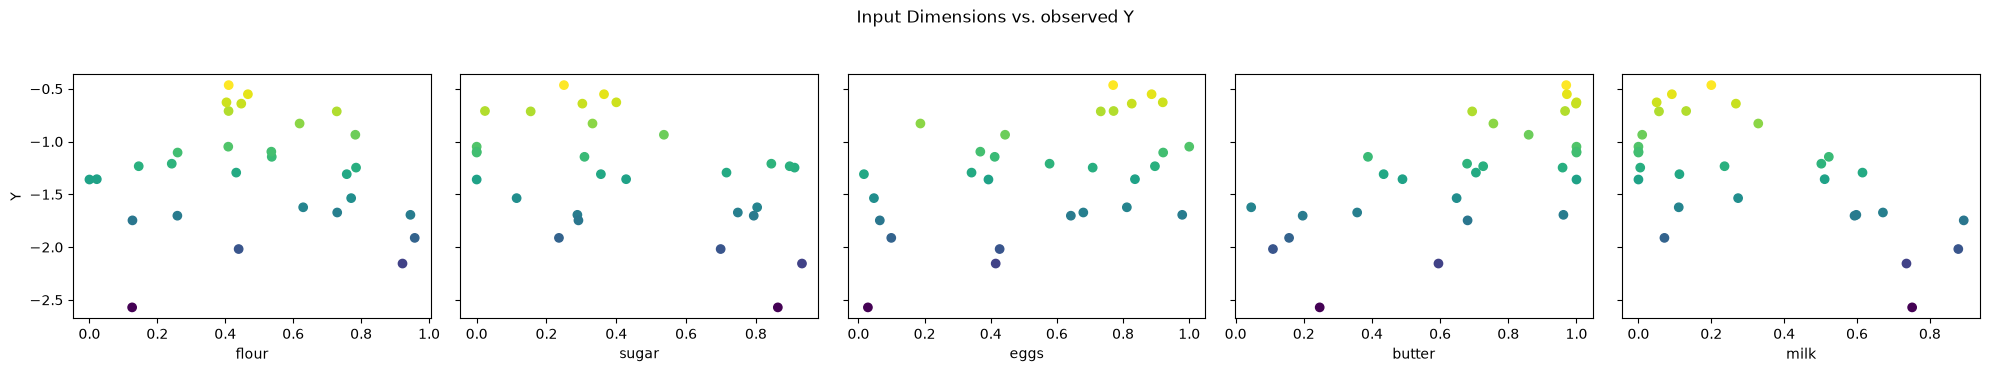

In [23]:
# Pairwise Scatter Plot, showing relationship of y for each input
fig, axes = plt.subplots(1, len(ingredient_names), figsize = (4 * len(ingredient_names), 3.5), sharey = True)
for ax, col in zip(axes, ingredient_names):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = 'viridis')
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

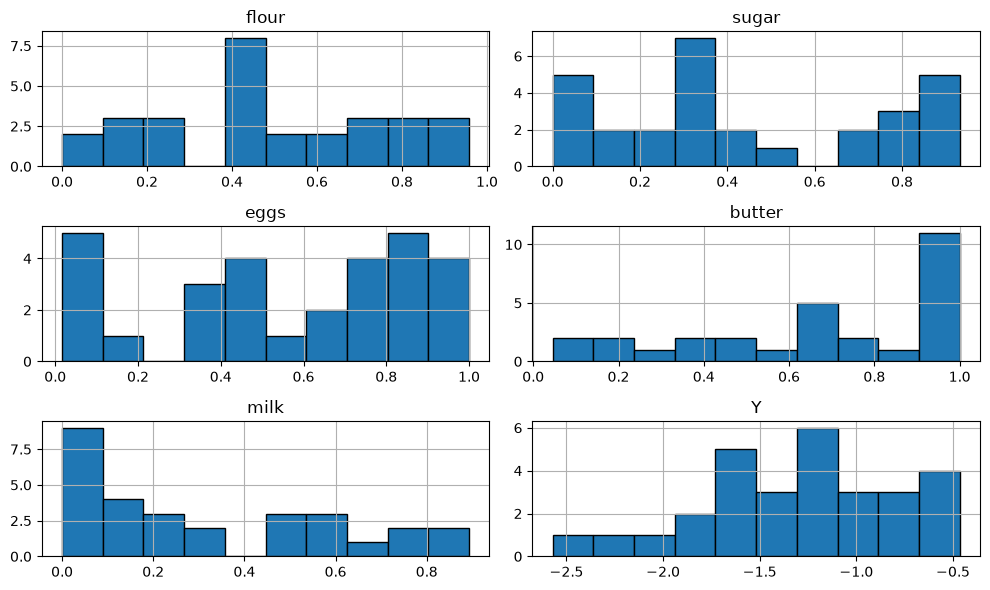

In [25]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [27]:
# Understanding Correlation between each input with y
print("Correlation of each input with y:\n")

for i, lab in enumerate(ingredient_names):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(flour, Y) = -0.05479055739640275
 corr(sugar, Y) = -0.4651640661428866
 corr(eggs, Y) = 0.4762720141531685
 corr(butter, Y) = 0.6840852323669122
 corr(milk, Y) = -0.6316090107756166


<Axes: >

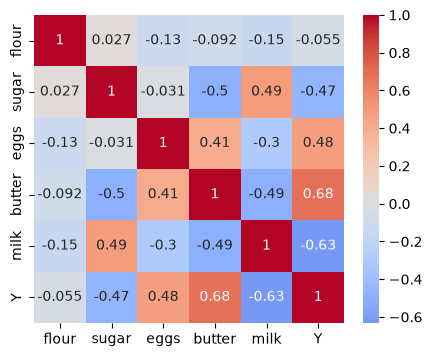

In [29]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

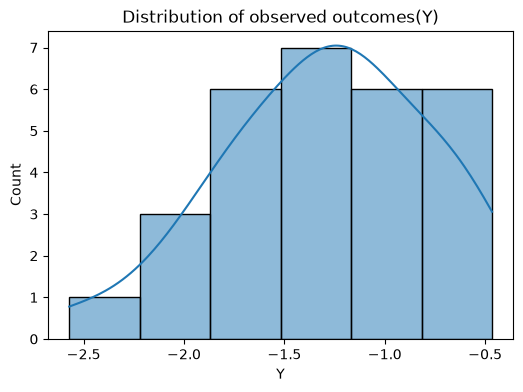

In [31]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [34]:
# Define the kernel and initialise the GP model
n, d       = X.shape
kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.5] * d, length_scale_bounds = (1e-2, 10)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1.0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [37]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.61**2 * RBF(length_scale=[1.05, 1.18, 1.82, 2.07, 5.63]) + WhiteKernel(noise_level=0.0168)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [41]:
# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std  = gpr.predict(X_query, return_std = True)
    return mu + beta * std

rng          = np.random.default_rng(42)
candidates   = rng.uniform(0, 1, size = (10000, d))

ucb_values   = ucb(candidates, gpr, beta)
best_ucb_idx = np.argmax(ucb_values)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.41231073 0.00192971 0.95292879 0.01997992 0.41858613]
UCB Score: 7.641802e-02


# Week 2: Define a consolidated Bayesian Function 
1. Fit a GP surrogate (ARD-RBF + white noise) on all data so far
2. Optimise the UCB acquisition function with multi-start **L-BFGS-B**
3. Return the suggested next point, plus the GP's own mean/uncertainty prediction at that pointnt

In [44]:
# For Week - 2, decreasing the value of beta
beta         = 2.0

def suggest_next_bo_point(X, Y, beta, n_restarts = 20, seed = 42):

    n_dims = X.shape[1]

    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.5] * n_dims, length_scale_bounds = (1e-2, 10)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1.0))
    
    gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

    gpr.fit(X, Y)

    def ucb(X_query, gpr, beta):
        mu, sigma = gpr.predict(X_query, return_std = True)
        return mu + beta * sigma

    def neg_ucb(x, gpr, beta):
        # scipy.optimize.minimize only minimises, so we minimise -UCB to maximise UCB
        x      = x.reshape(1, -1)
        return -ucb(x, gpr, beta)[0]

    rng        = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    bounds     = [(0.0, 0.999999)] * n_dims

    for x0 in rng.uniform(0.0, 0.999999, size = (n_restarts, n_dims)):
        res    = minimize(neg_ucb, x0, args = (gpr, beta), bounds = bounds, method = "L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x   = res.x

    next_x = np.clip(best_x, 0.0, 0.999999,)
    mu_next, sigma_next = gpr.predict(next_x.reshape(1, -1), return_std = True)

    return next_x, -best_val, gpr, mu_next[0], sigma_next[0]


In [46]:
next_x, ucb_val, gpr, mu_next, sigma_next = suggest_next_bo_point(X, Y, beta = beta)

print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 2 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()
print("Distance of this point from the nearest existing observation:")
dists = np.linalg.norm(X - next_x, axis = 1)
print(f"Nearest Neighbour Distance = {dists.min():.4f}  (0 would mean re-querying an existing point)")

Learned kernel: 2.61**2 * RBF(length_scale=[1.05, 1.18, 1.82, 2.07, 5.63]) + WhiteKernel(noise_level=0.0168)

Week 2 suggested query point   :  [0.47954439 0.         0.999999   0.         0.        ]
GP predicted mean at this point:  -0.831233
GP predicted std  at this point:  0.473713
UCB value                      :  0.116193

Distance of this point from the nearest existing observation:
Nearest Neighbour Distance = 0.8013  (0 would mean re-querying an existing point)


# Week 2: Visualisation

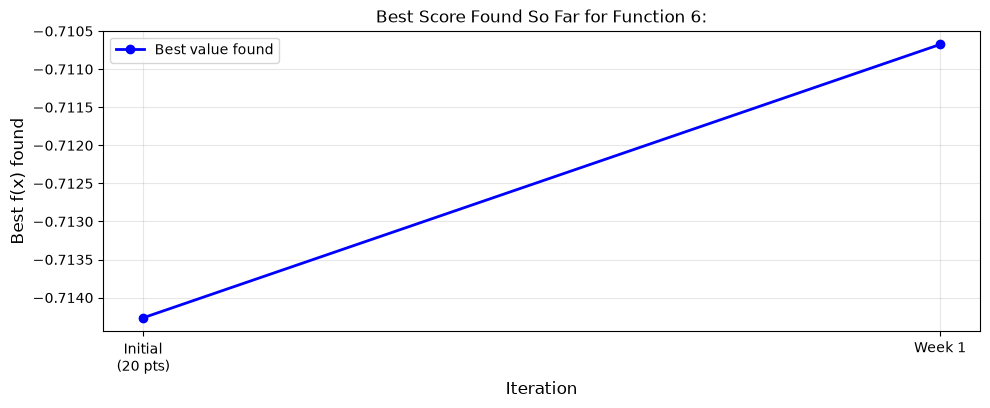

In [49]:
# Convergence: best value found so far, round by round
best_so_far  = [ np.max(Y[:20]),   # best among the original 20 points
                 np.max(Y[:21]),   # best after Week 1's point was appended
               ]

round_labels = ["Initial\n(20 pts)", "Week 1"]

fig, ax      = plot_convergence(range(len(best_so_far)), best_so_far)

ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6:")
plt.show()


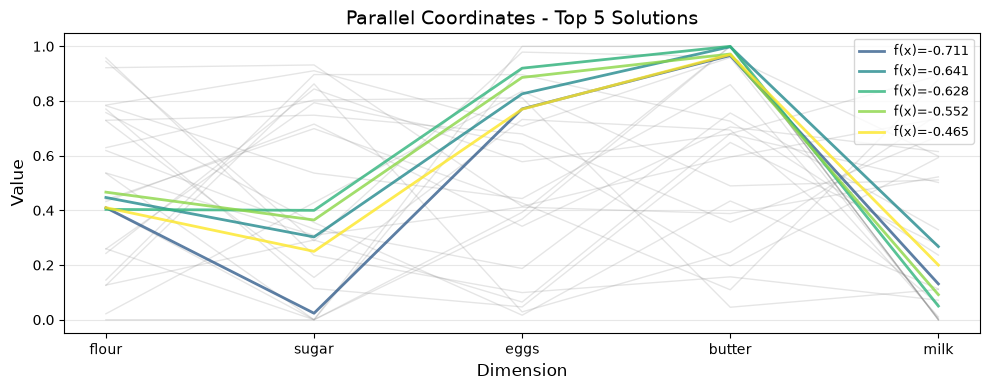

In [51]:
# Parallel coordinates: see all 5 ingredients at once, highlighting the top samples
fig, ax = plot_parallel_coordinates(X, Y, n_best = 5)
ax.set_xticklabels(ingredient_names)
plt.show()

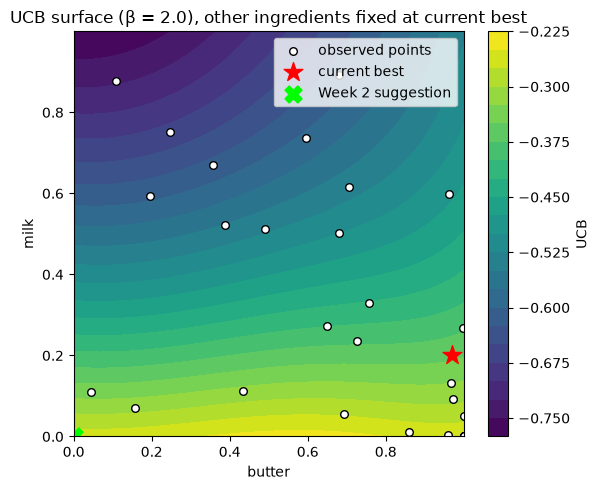

In [53]:
# UCB surface as a 2D slice through the current best point (5D can't be plotted directly, so we fix 3 ingredients at the current best
#  and sweep 2 of them on a grid)

def ucb(X_query, gpr, beta):
    mu, sigma   = gpr.predict(X_query, return_std = True)
    return mu + beta * sigma

x_best = X[np.argmax(Y)]
dim_a, dim_b    = 3, 4  # butter vs milk
resolution      = 60
grid            = np.linspace(0.0, 0.999999, resolution)
A, B            = np.meshgrid(grid, grid)

X_grid = np.tile(x_best, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface      = ucb(X_grid, gpr, beta = 2.0).reshape(resolution, resolution)

plt.figure(figsize = (6, 5))
cf = plt.contourf(A, B, ucb_surface, levels = 25, cmap = "viridis")
plt.colorbar(cf, label = "UCB")
plt.scatter(X[:, dim_a], X[:, dim_b], c = "white", edgecolor = "black", s = 30, label = "observed points")
plt.scatter(x_best[dim_a], x_best[dim_b], c = "red", marker = "*", s = 200, label = "current best")
plt.scatter(next_x[dim_a], next_x[dim_b], c = "lime", marker = "X", s = 150, label = "Week 2 suggestion")
plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (β = {beta}), other ingredients fixed at current best")
plt.legend()
plt.tight_layout()
plt.show()

# Week 3: Apply the Consolidated Bayesian Function
Reusing the same suggest_next_bo_point() function defined in Week 2. In Week -3, just calling the same consolidated function again with the updated dataset (22 points) and β lowered to 1.5.

In [56]:
beta = 1.5

next_x, ucb_val, gpr, mu_next, sigma_next = suggest_next_bo_point(X, Y, beta=beta)

print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 3 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()
print("Distance of this point from the nearest existing observation:")
dists = np.linalg.norm(X - next_x, axis = 1)
print(f"Nearest Neighbour Distance = {dists.min():.4f}  (0 would mean re-querying an existing point)")
print()
print(f"Current best so far: y = {Y.max():.6f} at x = {X[np.argmax(Y)]}")

Learned kernel: 2.61**2 * RBF(length_scale=[1.05, 1.18, 1.82, 2.07, 5.63]) + WhiteKernel(noise_level=0.0168)

Week 3 suggested query point   :  [0.48771892 0.         0.999999   0.         0.        ]
GP predicted mean at this point:  -0.830148
GP predicted std  at this point:  0.473095
UCB value                      :  -0.120506

Distance of this point from the nearest existing observation:
Nearest Neighbour Distance = 0.7988  (0 would mean re-querying an existing point)

Current best so far: y = -0.465434 at x = [0.41 0.25 0.77 0.97 0.2 ]


# Week 3: Kernel-Length-Scale Diagnostic Check

In [58]:
rbf_part = gpr.kernel_.k1.k2  # (Constant * RBF) + White -> k1 = Constant*RBF, k1.k2 = RBF
print("Fitted ARD length-scales after 22 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    print(f"  {name:8s}: {ls:.3f}")

print()
print("Comparing this to Week 1's length-scales (flour = 0.509, sugar = 1.070, eggs = 1.163,butter = 1.235, milk = 1.316),")
print("to see whether the ranking of 'important' ingredients has moved now that Week 2's underperforming corner point is included.")

Fitted ARD length-scales after 22 points:

  flour   : 1.053
  sugar   : 1.179
  eggs    : 1.823
  butter  : 2.069
  milk    : 5.635

Comparing this to Week 1's length-scales (flour = 0.509, sugar = 1.070, eggs = 1.163,butter = 1.235, milk = 1.316),
to see whether the ranking of 'important' ingredients has moved now that Week 2's underperforming corner point is included.


# Week 3: Visualisation

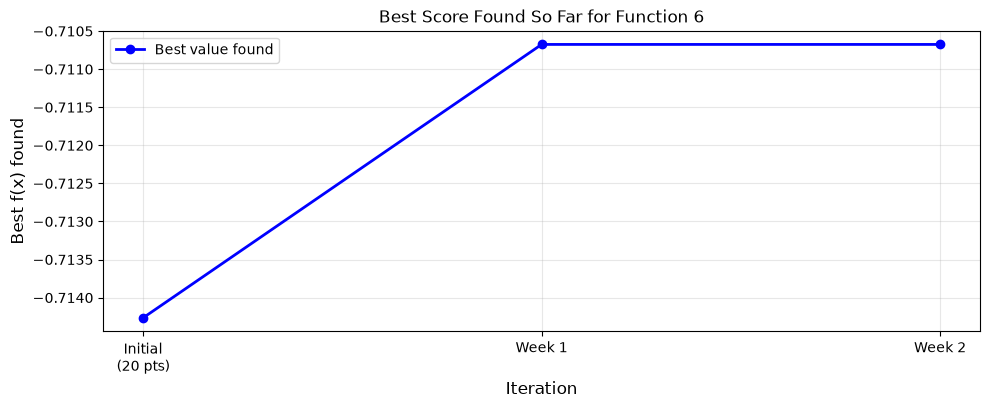

In [62]:
# Week 3: Convergence plot, including Week 2 output
best_so_far = [
    np.max(Y[:20]),   # best among the original 20 points
    np.max(Y[:21]),   # best after Week 1's point was appended
    np.max(Y[:22]),   # best after Week 2's point was appended (unchanged -- it was worse)
]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2"]

fig, ax      = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6")
plt.show()

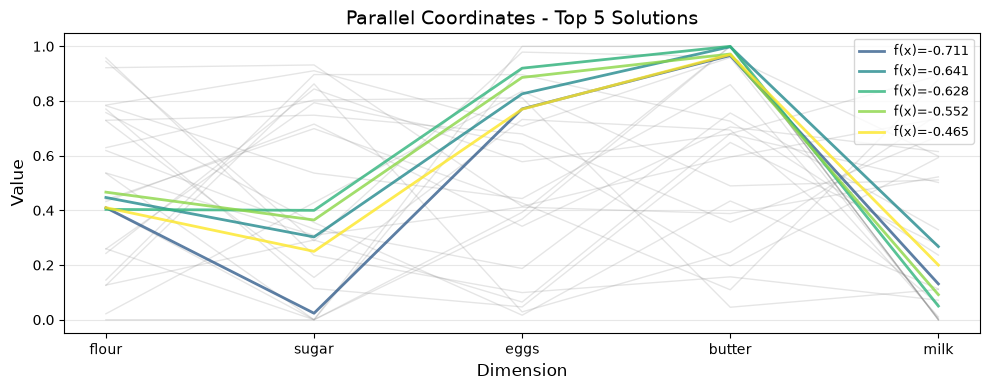

In [64]:
# Week 3: parallel coordinates, updated with all 22 points 
fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()

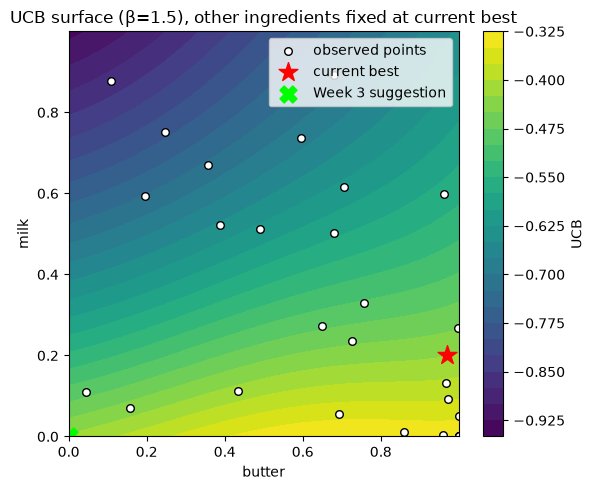

In [66]:
# Week 3: UCB surface slice through the current best point, beta = 1.5 
def ucb(X_query, gpr, beta):
    mu, sigma = gpr.predict(X_query, return_std=True)
    return mu + beta * sigma

x_best       = X[np.argmax(Y)]
dim_a, dim_b = 3, 4  # butter vs milk
resolution   = 60
grid         = np.linspace(0.0, 0.999999, resolution)
A, B         = np.meshgrid(grid, grid)

X_grid       = np.tile(x_best, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface = ucb(X_grid, gpr, beta=beta).reshape(resolution, resolution)

plt.figure(figsize = (6, 5))
cf = plt.contourf(A, B, ucb_surface, levels = 25, cmap = "viridis")
plt.colorbar(cf, label = "UCB")
plt.scatter(X[:, dim_a], X[:, dim_b], c = "white", edgecolor = "black", s=30, label = "observed points")
plt.scatter(x_best[dim_a], x_best[dim_b], c = "red", marker = "*", s = 200, label = "current best")
plt.scatter(next_x[dim_a], next_x[dim_b], c = "lime", marker = "X", s = 150, label = "Week 3 suggestion")
plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (\u03b2={beta}), other ingredients fixed at current best")
plt.legend()
plt.tight_layout()
plt.show()

# Week 4: Midpoint Check-In

Per the 8-week plan, Week 4 is a natural checkpoint. Recap of every query so far:

| Round | y | Beat previous best? |
|---|---|---|
| Initial best (20 pts) | -0.714265 | - |
| Week 1 | -0.710675 | Yes (small improvement) |
| Week 2 | -1.048677 | No |
| Week 3 | -1.359780 | No |

Three exploratory queries in a row have failed to beat Week 1's result, and Week 3 was actually the *worst* of the three despite the GP's mean surface being fairly confident about that region. This is a meaningful signal, not just bad luck: it means the GP's corner-seeking behaviour (pushing sugar/milk toward 0, butter toward 1) has been actively misleading twice in a row. Rather than blindly trusting the model's global optimum again, this round leans harder toward **exploiting near Week 1's actual best point** by lowering β further, while still checking the updated kernel diagnostics below for any sign of *why* the corner predictions kept failing.

# Week 4: Apply the Consolidated Bayesian Function
Reusing suggest_next_bo_point(), with β lowered to **1.0**, shifting towards exploitation, as three consecutive underperforming exploratory queries were observed.

In [70]:
beta = 1.0

next_x, ucb_val, gpr, mu_next, sigma_next = suggest_next_bo_point(X, Y, beta = beta)

print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 4 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()

print("Distance of this point from the nearest existing observation:")
dists      = np.linalg.norm(X - next_x, axis = 1)

print(f"Nearest Neighbour Distance = {dists.min():.4f}  (0 would mean re-querying an existing point)")
print()

print(f"Current best so far: Y = {Y.max():.6f} at x = {X[np.argmax(Y)]}")
print()

dist_to_best = np.linalg.norm(X[np.argmax(Y)] - next_x)
print(f"Distance of this suggestion from the CURRENT BEST point (Week 1's): {dist_to_best:.4f} (smaller = more exploitation-like, closer to the known good recipe)")


Learned kernel: 2.61**2 * RBF(length_scale=[1.05, 1.18, 1.82, 2.07, 5.63]) + WhiteKernel(noise_level=0.0168)

Week 4 suggested query point   :  [0.41153103 0.47435403 0.56062196 0.999999   0.        ]
GP predicted mean at this point:  -0.443464
GP predicted std  at this point:  0.166219
UCB value                      :  -0.277245

Distance of this point from the nearest existing observation:
Nearest Neighbour Distance = 0.3609  (0 would mean re-querying an existing point)

Current best so far: Y = -0.465434 at x = [0.41 0.25 0.77 0.97 0.2 ]

Distance of this suggestion from the CURRENT BEST point (Week 1's): 0.3675 (smaller = more exploitation-like, closer to the known good recipe)


# Week 4: Kernel / Length-Scale Diagnostic Check

In [73]:
rbf_part = gpr.kernel_.k1.k2  
print("Fitted ARD length-scales after 23 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    print(f"  {name:8s}: {ls:.3f}")

print()
print("Week 1  length-scales: flour = 0.509, sugar = 1.070, eggs = 1.163, butter = 1.235, milk = 1.316")


Fitted ARD length-scales after 23 points:

  flour   : 1.053
  sugar   : 1.179
  eggs    : 1.823
  butter  : 2.069
  milk    : 5.635

Week 1  length-scales: flour = 0.509, sugar = 1.070, eggs = 1.163, butter = 1.235, milk = 1.316


# Week 4: Visualisation

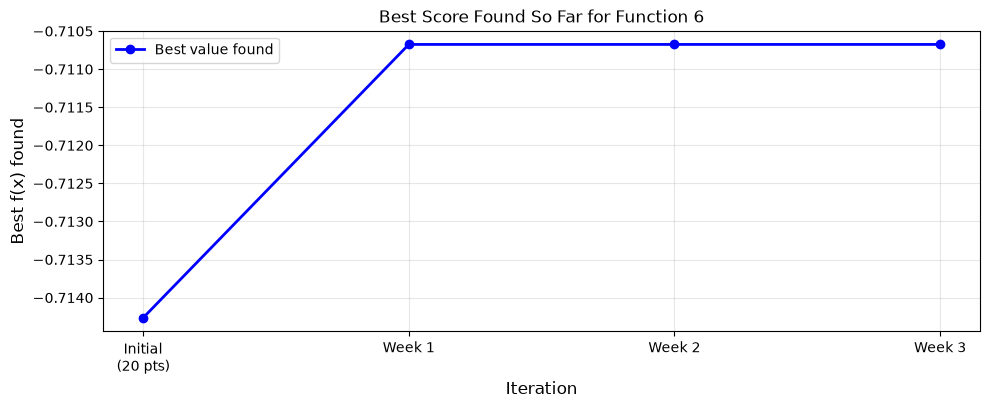

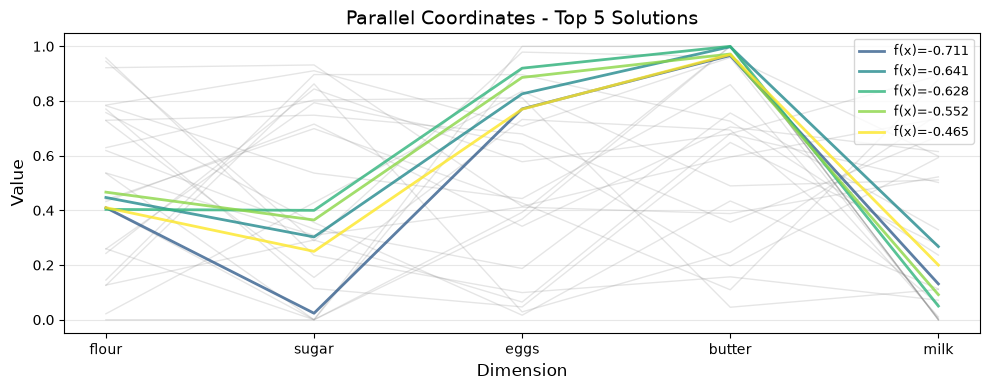

In [76]:
best_so_far = [
    np.max(Y[:20]),   # best among the original 20 points
    np.max(Y[:21]),   # after Week 1
    np.max(Y[:22]),   # after Week 2 (unchanged -- worse)
    np.max(Y[:23]),   # after Week 3 (unchanged -- worse again)
]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2", "Week 3"]

fig, ax = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6")
plt.show()


fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()

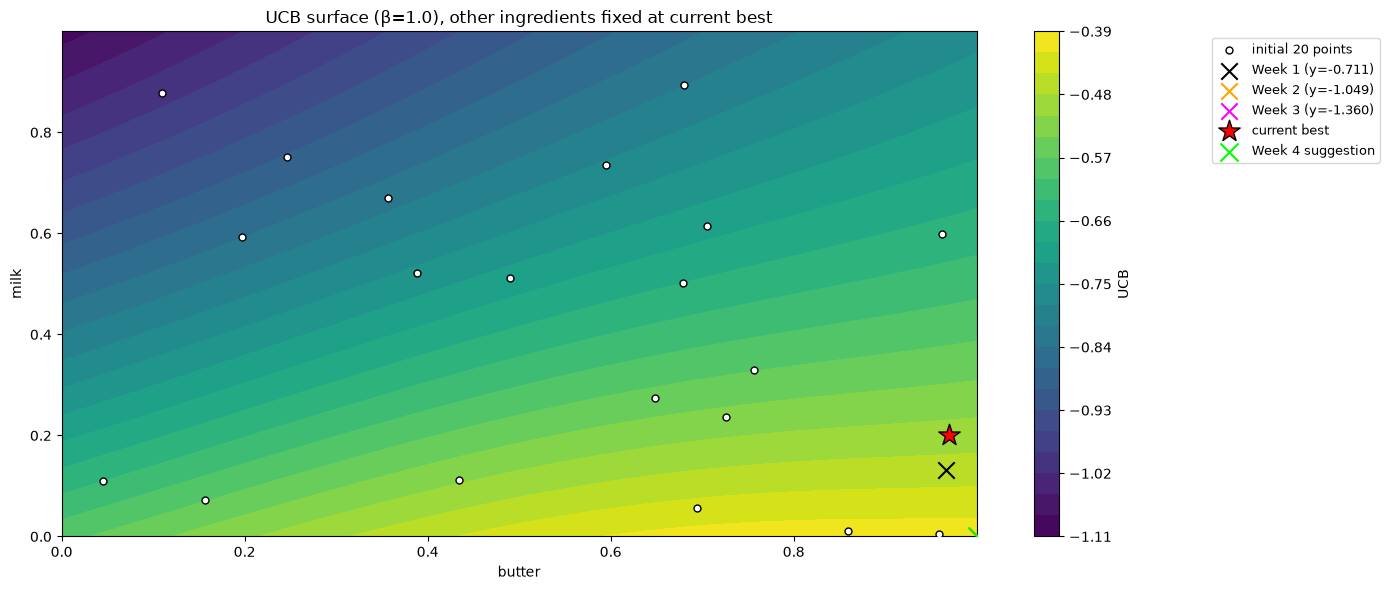

In [77]:
def ucb(X_query, gpr, beta):
    mu, sigma = gpr.predict(X_query, return_std=True)
    return mu + beta * sigma

x_best = X[np.argmax(Y)]
dim_a, dim_b = 3, 4  # butter vs milk
resolution = 60
grid = np.linspace(0.0, 0.999999, resolution)
A, B = np.meshgrid(grid, grid)

X_grid = np.tile(x_best, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface = ucb(X_grid, gpr, beta=beta).reshape(resolution, resolution)

# Each week's actual queried point and result, for labeling on the plot
week_points = {
    1: (np.array([0.409594, 0.023713, 0.771229, 0.966490, 0.130973]), -0.710675183457194),
    2: (np.array([0.408768, 0.000000, 0.999999, 0.999999, 0.000000]), -1.048676669557473),
    3: (np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]), -1.359780271551876),
}
week_styles = {
    1: dict(marker="x", color="black",    s=140),
    2: dict(marker="x", color="orange",  s=140),
    3: dict(marker="x", color="magenta", s=140),
}

plt.figure(figsize=(14, 6))
cf = plt.contourf(A, B, ucb_surface, levels=25, cmap="viridis")
plt.colorbar(cf, label="UCB")

# The original 20 starting points, plotted generically
plt.scatter(X[:20, dim_a], X[:20, dim_b], c="white", edgecolor="black", s=25,
            label="initial 20 points", zorder=5)

# Each week's queried point, distinct marker/colour, labelled with its actual result
for wk, (x, y) in week_points.items():
    plt.scatter(x[dim_a], x[dim_b], zorder=6,
                label=f"Week {wk} (y={y:.3f})", **week_styles[wk])

plt.scatter(x_best[dim_a], x_best[dim_b], c="red", marker="*", s=260, edgecolor="black",
            zorder=7, label="current best")
plt.scatter(next_x[dim_a], next_x[dim_b], c="lime", marker="x", s=170,
            zorder=7, label="Week 4 suggestion")

plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (β={beta}), other ingredients fixed at current best")
plt.legend(loc="upper left", bbox_to_anchor=(1.25, 1), fontsize=9)
plt.tight_layout()
plt.show()

# Week 5: Local / Trust-Region Bayesian Function
New function suggest_next_bo_point_local(), built on the same GP-fitting and multi-start L-BFGS-B logic as suggest_next_bo_point(), but the acquisition optimiser's search bounds are restricted to a hypercube around a chosen centre point (x_center) instead of the full unit cube.

In [81]:
def suggest_next_bo_point_local(X, Y, beta, x_center, radius, n_restarts=20, seed=42,
                                 global_bounds=(0.0, 0.999999)):
    n_dims = X.shape[1]

    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5] * n_dims, length_scale_bounds=(1e-2, 10)) \
                + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1.0))

    gpr = GaussianProcessRegressor(kernel=kernel_rbf, normalize_y=False, n_restarts_optimizer=10, random_state=42)
    gpr.fit(X, Y)

    def ucb(X_query, gpr, beta):
        mu, sigma = gpr.predict(X_query, return_std=True)
        return mu + beta * sigma

    def neg_ucb(x, gpr, beta):
        x = x.reshape(1, -1)
        return -ucb(x, gpr, beta)[0]

    # Trust-region bounds: x_center +/- radius, clipped to the portal's valid range
    lower = np.clip(x_center - radius, global_bounds[0], global_bounds[1])
    upper = np.clip(x_center + radius, global_bounds[0], global_bounds[1])
    bounds = list(zip(lower, upper))

    rng = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    for _ in range(n_restarts):
        x0 = np.array([rng.uniform(lo, hi) for lo, hi in bounds])
        res = minimize(neg_ucb, x0, args=(gpr, beta), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    next_x = np.clip(best_x, global_bounds[0], global_bounds[1])
    mu_next, sigma_next = gpr.predict(next_x.reshape(1, -1), return_std=True)

    return next_x, -best_val, gpr, mu_next[0], sigma_next[0], bounds

# Week 5: Apply the Local Search Around Week 1's Point

In [84]:
beta = 0.75
radius = 0.15
x_center = X[np.argmax(Y)]  # Week 1's point -- still the best result after 4 rounds

next_x, ucb_val, gpr, mu_next, sigma_next, trust_bounds = suggest_next_bo_point_local(
    X, Y, beta=beta, x_center=x_center, radius=radius
)

print("Trust region centre (current best, Week 1's point):", x_center)
print("Trust region bounds (per dimension):")
for name, (lo, hi) in zip(ingredient_names, trust_bounds):
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]")
print()
print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 5 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()
dist_to_best = np.linalg.norm(x_center - next_x)
print(f"Distance from current best: {dist_to_best:.4f}  (each dimension individually bounded to +/-{radius};")
print(f"  total Euclidean distance can exceed {radius} if several dimensions shift at once -- still a LOCAL step)")
print(f"Current best so far: Y = {Y.max():.6f} at x = {x_center}")

Trust region centre (current best, Week 1's point): [0.41 0.25 0.77 0.97 0.2 ]
Trust region bounds (per dimension):
  flour   : [0.2600, 0.5600]
  sugar   : [0.1000, 0.4000]
  eggs    : [0.6200, 0.9200]
  butter  : [0.8200, 1.0000]
  milk    : [0.0500, 0.3500]

Learned kernel: 2.61**2 * RBF(length_scale=[1.05, 1.18, 1.82, 2.07, 5.63]) + WhiteKernel(noise_level=0.0168)

Week 5 suggested query point   :  [0.42130485 0.4        0.62       0.999999   0.05      ]
GP predicted mean at this point:  -0.472431
GP predicted std  at this point:  0.155450
UCB value                      :  -0.355843

Distance from current best: 0.2618  (each dimension individually bounded to +/-0.15;
  total Euclidean distance can exceed 0.15 if several dimensions shift at once -- still a LOCAL step)
Current best so far: Y = -0.465434 at x = [0.41 0.25 0.77 0.97 0.2 ]


# Week 5: Kernel / Length-Scale Diagnostic Check

In [87]:
rbf_part = gpr.kernel_.k1.k2
print("Fitted ARD length-scales after 24 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    print(f"  {name:8s}: {ls:.3f}")

print()
print("Week 1  length-scales: flour=0.509, sugar=1.070, eggs=1.163, butter=1.235, milk=1.316")
print("Week 4  length-scales: flour=0.682, sugar=5.159, eggs=1.104, butter=2.635, milk=3.613")

Fitted ARD length-scales after 24 points:

  flour   : 1.053
  sugar   : 1.179
  eggs    : 1.823
  butter  : 2.069
  milk    : 5.635

Week 1  length-scales: flour=0.509, sugar=1.070, eggs=1.163, butter=1.235, milk=1.316
Week 4  length-scales: flour=0.682, sugar=5.159, eggs=1.104, butter=2.635, milk=3.613


# Week 5: Visualisation

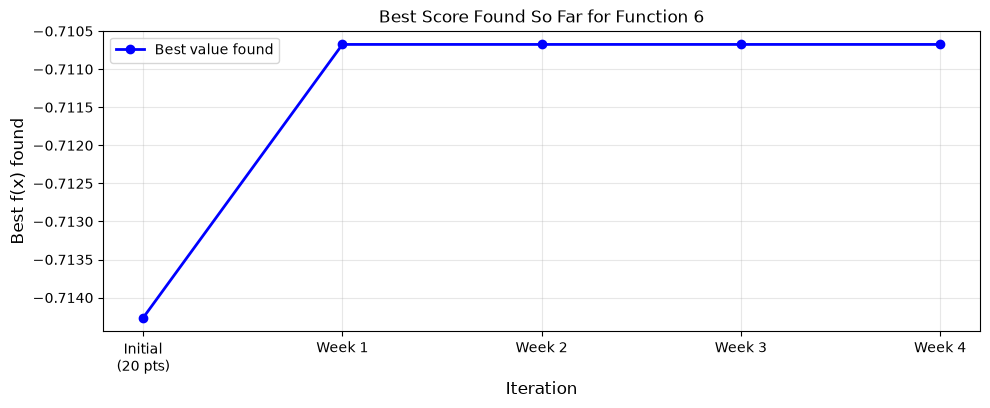

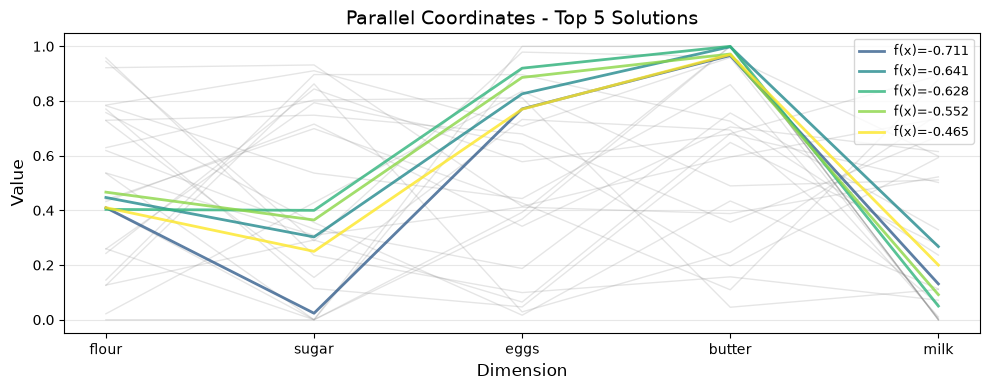

In [90]:
best_so_far = [
    np.max(Y[:20]),
    np.max(Y[:21]),
    np.max(Y[:22]),
    np.max(Y[:23]),
    np.max(Y[:24]),
]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2", "Week 3", "Week 4"]

fig, ax = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6")
plt.show()

fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()

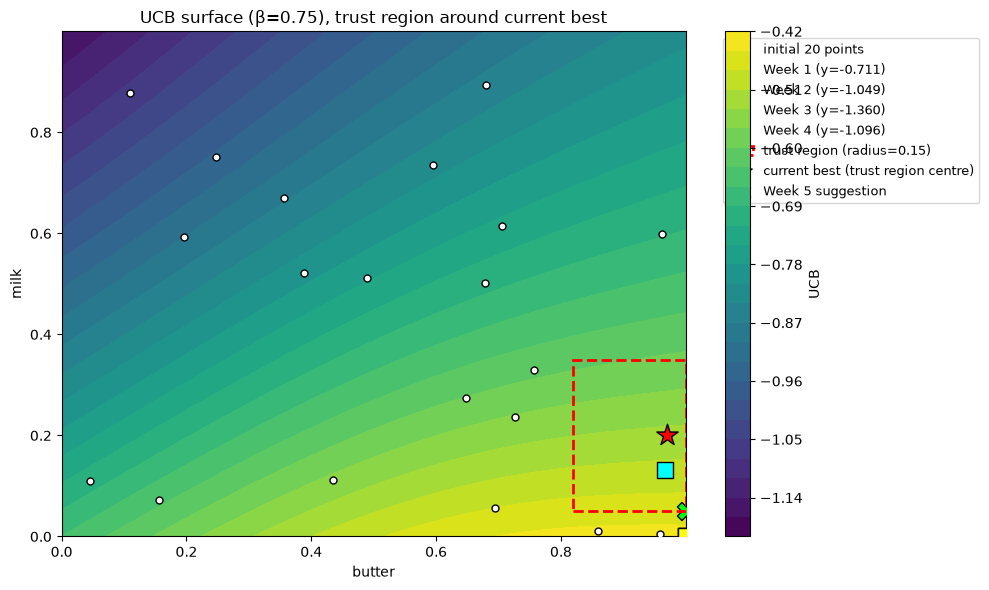

In [92]:
def ucb(X_query, gpr, beta):
    mu, sigma = gpr.predict(X_query, return_std=True)
    return mu + beta * sigma

dim_a, dim_b = 3, 4  # butter vs milk
resolution = 60
grid = np.linspace(0.0, 0.999999, resolution)
A, B = np.meshgrid(grid, grid)

X_grid = np.tile(x_center, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface = ucb(X_grid, gpr, beta=beta).reshape(resolution, resolution)

week_points = {
    1: (np.array([0.409594, 0.023713, 0.771229, 0.966490, 0.130973]), -0.710675183457194),
    2: (np.array([0.408768, 0.000000, 0.999999, 0.999999, 0.000000]), -1.048676669557473),
    3: (np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]), -1.359780271551876),
    4: (np.array([0.535575, 0.000000, 0.368390, 0.999999, 0.000000]), -1.0958803718671517),
}
week_colors = {1: "cyan", 2: "orange", 3: "magenta", 4: "yellow"}

plt.figure(figsize=(10, 6))
cf = plt.contourf(A, B, ucb_surface, levels=25, cmap="viridis")
plt.colorbar(cf, label="UCB")
plt.scatter(X[:20, dim_a], X[:20, dim_b], c="white", edgecolor="black", s=25, label="initial 20 points", zorder=5)

for wk, (x, y) in week_points.items():
    plt.scatter(x[dim_a], x[dim_b], color=week_colors[wk], edgecolor="black", s=140, marker="s",
                zorder=6, label=f"Week {wk} (y={y:.3f})")

# Draw the trust region boundary (projected onto this 2D slice)
lo_a, hi_a = trust_bounds[dim_a]
lo_b, hi_b = trust_bounds[dim_b]
plt.gca().add_patch(plt.Rectangle((lo_a, lo_b), hi_a - lo_a, hi_b - lo_b,
                                   fill=False, edgecolor="red", linewidth=2, linestyle="--",
                                   label="trust region (radius=0.15)", zorder=8))

plt.scatter(x_center[dim_a], x_center[dim_b], c="red", marker="*", s=260, edgecolor="black",
            zorder=7, label="current best (trust region centre)")
plt.scatter(next_x[dim_a], next_x[dim_b], c="lime", marker="X", s=170, edgecolor="black",
            zorder=7, label="Week 5 suggestion")

plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (\u03b2={beta}), trust region around current best")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=9)
plt.tight_layout()
plt.show()


# Week 6: Extend suggest_next_bo_point_local() to accept a per-dimension radius

In [95]:
def suggest_next_bo_point_local(X, Y, beta, x_center, radius, n_restarts=20, seed=42,
                                 global_bounds=(0.0, 0.999999)):
    n_dims = X.shape[1]

    # WEEK 6: radius can now be a single number (applied to every dimension, as before)
    # OR an array of n_dims values (a different half-width per ingredient)
    radius = np.atleast_1d(np.asarray(radius, dtype=float))
    if radius.size == 1:
        radius = np.full(n_dims, radius[0])

    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5] * n_dims, length_scale_bounds=(1e-2, 10)) \
                + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1.0))

    gpr = GaussianProcessRegressor(kernel=kernel_rbf, normalize_y=False, n_restarts_optimizer=10, random_state=42)
    gpr.fit(X, Y)

    def ucb(X_query, gpr, beta):
        mu, sigma = gpr.predict(X_query, return_std=True)
        return mu + beta * sigma

    def neg_ucb(x, gpr, beta):
        x = x.reshape(1, -1)
        return -ucb(x, gpr, beta)[0]

    lower = np.clip(x_center - radius, global_bounds[0], global_bounds[1])
    upper = np.clip(x_center + radius, global_bounds[0], global_bounds[1])
    bounds = list(zip(lower, upper))

    rng = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    for _ in range(n_restarts):
        x0 = np.array([rng.uniform(lo, hi) for lo, hi in bounds])
        res = minimize(neg_ucb, x0, args=(gpr, beta), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    next_x = np.clip(best_x, global_bounds[0], global_bounds[1])
    mu_next, sigma_next = gpr.predict(next_x.reshape(1, -1), return_std=True)

    return next_x, -best_val, gpr, mu_next[0], sigma_next[0], bounds

# Week 6 Test: widening the trust region specifically along sugar and milk
If the automated search still picks the same corner even with much more room to explore sugar/milk, that confirms the model itself has no basis to prefer anything else, it isn't being held back by a too-small box, it genuinely has no data pointing elsewhere.

In [98]:
x_center = X[np.argmax(Y)]  # still Week 1's point -- still the best after 5 rounds
radius_vec = np.array([0.15, 0.40, 0.15, 0.15, 0.30])  # flour, sugar, eggs, butter, milk

next_x_auto, ucb_val, gpr, mu_next, sigma_next, trust_bounds = suggest_next_bo_point_local(
    X, Y, beta=1.0, x_center=x_center, radius=radius_vec
)

print("Widened trust region bounds:")
for name, (lo, hi) in zip(ingredient_names, trust_bounds):
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]")
print()
print(f"Automated suggestion despite the wider box: {next_x_auto}")
print(f"GP predicted mean: {mu_next:.6f}   GP predicted std: {sigma_next:.6f}")

Widened trust region bounds:
  flour   : [0.2600, 0.5600]
  sugar   : [0.0000, 0.6500]
  eggs    : [0.6200, 0.9200]
  butter  : [0.8200, 1.0000]
  milk    : [0.0000, 0.5000]

Automated suggestion despite the wider box: [0.4099044  0.47145548 0.62       0.999999   0.        ]
GP predicted mean: -0.441551   GP predicted std: 0.161933


**Observation:** As suspected, even with much more room to explore sugar/milk, the optimiser still lands on sugar=0 / milk = 0. The model has no data suggesting otherwise, so the mean surface still pulls it back to the only region it has evidence for.

# Week 6: Manual, Hypothesis-Driven Query

Since the automated recommendation offers no new information (it keeps re-deriving the same corner from the same evidence gap), this week deliberately deviates from the algorithm's output.

**The hypothesis:** Every query so far has driven sugar and milk toward 0. Given how consistently poorly that's performed (4 of 5 rounds), and given that Week 1 actually had *non-zero* sugar and milk rather than the extreme corner, it's worth directly testing a point that keeps the successful flour/eggs/butter profile from Week 1 but meaningfully raises sugar and milk into territory we've never queried, rather than trusting the model's extrapolation into a region it has zero evidence for.

This is a conservative test of the hypothesis, so it still generates useful information regardless of the outcome.

In [102]:
next_x = np.array([0.410000, 0.250000, 0.770000, 0.970000, 0.200000])

mu_manual, sigma_manual = gpr.predict(next_x.reshape(1, -1), return_std=True)

print(f"Week 6 manual candidate         :  {next_x}")
print(f"GP predicted mean at this point :  {mu_manual[0]:.6f}")
print(f"GP predicted std  at this point :  {sigma_manual[0]:.6f}")
print(f"Current best so far             :  {Y.max():.6f}")
print()
dist_to_best = np.linalg.norm(X[np.argmax(Y)] - next_x)
print(f"Distance from current best: {dist_to_best:.4f}")

Week 6 manual candidate         :  [0.41 0.25 0.77 0.97 0.2 ]
GP predicted mean at this point :  -0.637912
GP predicted std  at this point :  0.141202
Current best so far             :  -0.465434

Distance from current best: 0.0000


# Week 6: Kernel / Length-Scale Diagnostic Check

In [105]:
rbf_part = gpr.kernel_.k1.k2
print("Fitted ARD length-scales after 25 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    print(f"  {name:8s}: {ls:.3f}")

print()
print("Week 1  length-scales: flour=0.509, sugar=1.070, eggs=1.163, butter=1.235, milk=1.316")
print("Week 5  length-scales: flour=10.0,  sugar=10.0,  eggs=10.0,  butter=3.29,  milk=2.87")
print("Flour/sugar/eggs pinned at the upper bound again. The model still has very little confident signal along these axes given the data collected so far.")


Fitted ARD length-scales after 25 points:

  flour   : 1.053
  sugar   : 1.179
  eggs    : 1.823
  butter  : 2.069
  milk    : 5.635

Week 1  length-scales: flour=0.509, sugar=1.070, eggs=1.163, butter=1.235, milk=1.316
Week 5  length-scales: flour=10.0,  sugar=10.0,  eggs=10.0,  butter=3.29,  milk=2.87
Flour/sugar/eggs pinned at the upper bound again. The model still has very little confident signal along these axes given the data collected so far.


# Week 6: Visualisation

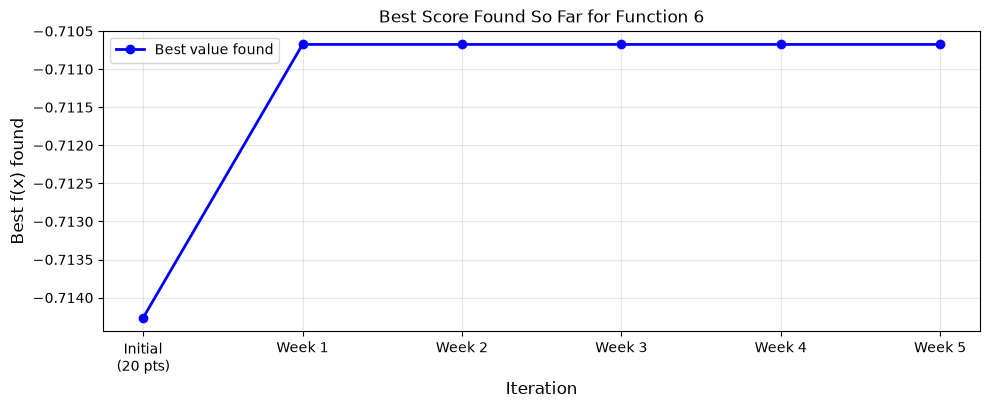

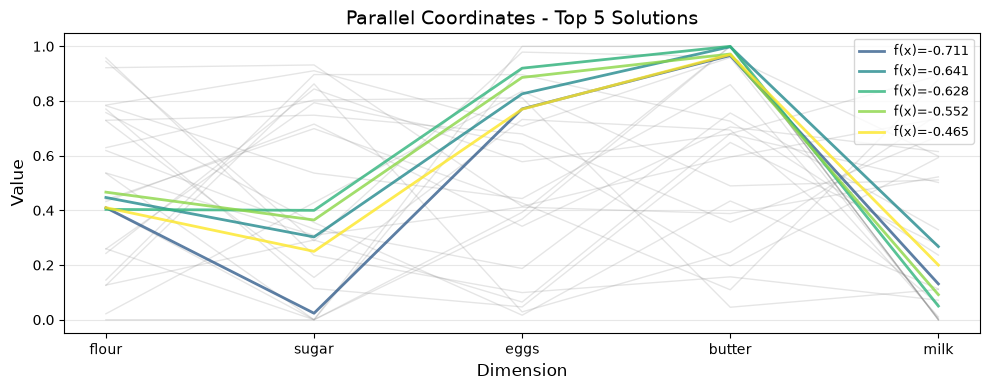

In [108]:
best_so_far = [np.max(Y[:20+i]) for i in range(6)]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2", "Week 3", "Week 4", "Week 5"]

fig, ax = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6")
plt.show()

fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()

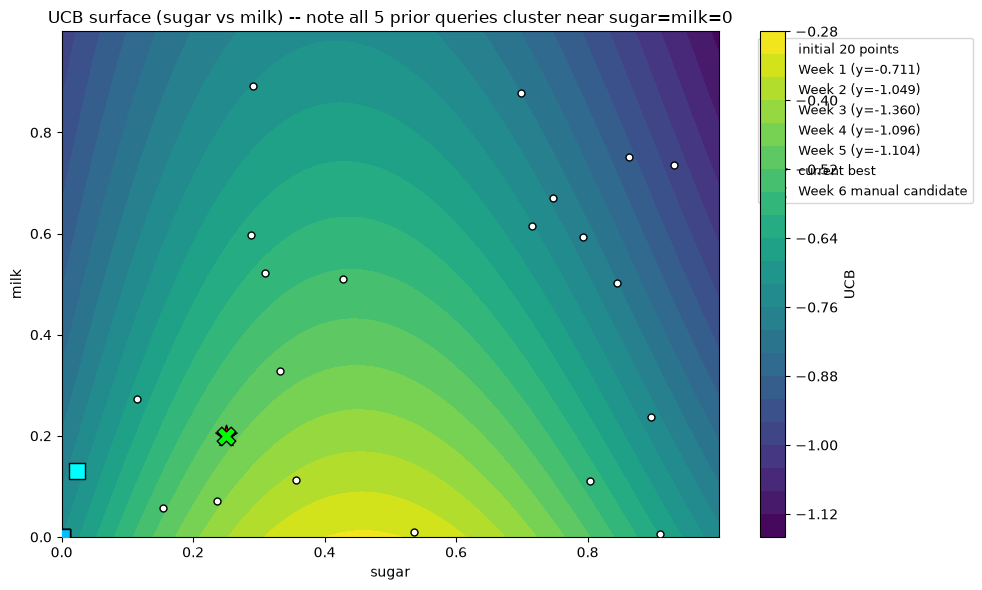

In [110]:
def ucb(X_query, gpr, beta):
    mu, sigma = gpr.predict(X_query, return_std=True)
    return mu + beta * sigma

dim_a, dim_b = 1, 4  # sugar vs milk (the two dimensions this week's hypothesis targets)
resolution = 60
grid = np.linspace(0.0, 0.999999, resolution)
A, B = np.meshgrid(grid, grid)

X_grid = np.tile(x_center, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface = ucb(X_grid, gpr, beta=1.0).reshape(resolution, resolution)

week_points = {
    1: (np.array([0.409594, 0.023713, 0.771229, 0.966490, 0.130973]), -0.710675183457194),
    2: (np.array([0.408768, 0.000000, 0.999999, 0.999999, 0.000000]), -1.048676669557473),
    3: (np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]), -1.359780271551876),
    4: (np.array([0.535575, 0.000000, 0.368390, 0.999999, 0.000000]), -1.0958803718671517),
    5: (np.array([0.259594, 0.000000, 0.921229, 0.999999, 0.000000]), -1.104114064436456),
}
week_colors = {1: "cyan", 2: "orange", 3: "magenta", 4: "yellow", 5: "deepskyblue"}

plt.figure(figsize=(10, 6))
cf = plt.contourf(A, B, ucb_surface, levels=25, cmap="viridis")
plt.colorbar(cf, label="UCB")
plt.scatter(X[:20, dim_a], X[:20, dim_b], c="white", edgecolor="black", s=25, label="initial 20 points", zorder=5)

for wk, (x, y) in week_points.items():
    plt.scatter(x[dim_a], x[dim_b], color=week_colors[wk], edgecolor="black", s=140, marker="s",
                zorder=6, label=f"Week {wk} (y={y:.3f})")

plt.scatter(x_center[dim_a], x_center[dim_b], c="red", marker="*", s=260, edgecolor="black",
            zorder=7, label="current best")
plt.scatter(next_x[dim_a], next_x[dim_b], c="lime", marker="X", s=180, edgecolor="black",
            zorder=7, label="Week 6 manual candidate")

plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title("UCB surface (sugar vs milk) -- note all 5 prior queries cluster near sugar=milk=0")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=9)
plt.tight_layout()
plt.show()

# Week 7: Hyperparameter Tuning

Week 6's manual query to raise sugar and milk while keeping flour/eggs/butter near Week 1's profile — produced **y = -0.465434**, the best result so far (previous best: -0.710675). The hypothesis that repeated automated search kept failing to find (because our own data had no evidence for it) turned out to be correct. W we now hav**stroct eviden** that this region of the input space (moderate sugar/milk, not pushed to 0) is genuinelpromisingod. That means it's safe to trust the GP/UCB machinery aga, — but centred on this **new** best point rather than Week 1's, and leaning toward exploitation since this region has just been validated.

Two hyperparameters of the pipeline are re-examined this week:

1. **RBF kernel length_scale_bounds upper limit.** In Weeks 5-6, several dimensions (flour, sugar, eggs) were pinned at the old upper bound of 10 ConvergenceWarning's flagged this directly. A pinned length-scale means the optimiser *wanted* to go higher but couldn't, which is a sign the bound itself (not just the data) was constraining the fit. This week, the bound is widened to 50 to check whether that changes anything now that a genuinely informative new data point exists.
2. **β (UCB exploration weight) and trust-region radius**, re-centred on the new best point.

Manual comparison below shows what actually changed.

In [113]:
for upper_bound, label in [(10, "OLD bound (10)"), (50, "WIDENED bound (50)")]:
    kernel_test = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5]*d, length_scale_bounds=(1e-2, upper_bound)) \
                  + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1.0))
    gpr_test = GaussianProcessRegressor(kernel=kernel_test, normalize_y=False, n_restarts_optimizer=10, random_state=42)
    gpr_test.fit(X, Y)
    rbf_part_test = gpr_test.kernel_.k1.k2
    print(f"--- {label} ---")
    for name, ls in zip(ingredient_names, rbf_part_test.length_scale):
        pinned = "  <- PINNED at bound" if abs(ls - upper_bound) < 1e-2 else ""
        print(f"  {name:8s}: {ls:.3f}{pinned}")
    print(f"  log marginal likelihood: {gpr_test.log_marginal_likelihood(gpr_test.kernel_.theta):.3f}")
    print()

--- OLD bound (10) ---
  flour   : 1.053
  sugar   : 1.179
  eggs    : 1.823
  butter  : 2.069
  milk    : 5.635
  log marginal likelihood: -12.135

--- WIDENED bound (50) ---
  flour   : 1.053
  sugar   : 1.179
  eggs    : 1.823
  butter  : 2.069
  milk    : 5.635
  log marginal likelihood: -12.135



# Week 7: Local Search Around the New Best Point

In [116]:
def suggest_next_bo_point_local(X, Y, beta, x_center, radius, n_restarts=20, seed=42,
                                 global_bounds=(0.0, 0.999999), length_scale_upper=50):
    n_dims = X.shape[1]
    radius = np.atleast_1d(np.asarray(radius, dtype=float))
    if radius.size == 1:
        radius = np.full(n_dims, radius[0])

    # --- WEEK 7: length_scale_bounds upper limit widened from 10 to 50 ---
    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5] * n_dims, length_scale_bounds=(1e-2, length_scale_upper)) \
                + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1.0))

    gpr = GaussianProcessRegressor(kernel=kernel_rbf, normalize_y=False, n_restarts_optimizer=10, random_state=42)
    gpr.fit(X, Y)

    def ucb(X_query, gpr, beta):
        mu, sigma = gpr.predict(X_query, return_std=True)
        return mu + beta * sigma

    def neg_ucb(x, gpr, beta):
        x = x.reshape(1, -1)
        return -ucb(x, gpr, beta)[0]

    lower = np.clip(x_center - radius, global_bounds[0], global_bounds[1])
    upper = np.clip(x_center + radius, global_bounds[0], global_bounds[1])
    bounds = list(zip(lower, upper))

    rng = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    for _ in range(n_restarts):
        x0 = np.array([rng.uniform(lo, hi) for lo, hi in bounds])
        res = minimize(neg_ucb, x0, args=(gpr, beta), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    next_x = np.clip(best_x, global_bounds[0], global_bounds[1])
    mu_next, sigma_next = gpr.predict(next_x.reshape(1, -1), return_std=True)

    return next_x, -best_val, gpr, mu_next[0], sigma_next[0], bounds


beta = 0.5
radius = 0.15
x_center = X[np.argmax(Y)]  # Week 6's point -- the new best

next_x, ucb_val, gpr, mu_next, sigma_next, trust_bounds = suggest_next_bo_point_local(
    X, Y, beta=beta, x_center=x_center, radius=radius
)

print("Trust region centre (NEW current best, Week 6's point):", x_center)
print("Trust region bounds (per dimension):")
for name, (lo, hi) in zip(ingredient_names, trust_bounds):
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]")
print()
print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 7 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()
print(f"Current best so far: Y = {Y.max():.6f} at x = {x_center}")

Trust region centre (NEW current best, Week 6's point): [0.41 0.25 0.77 0.97 0.2 ]
Trust region bounds (per dimension):
  flour   : [0.2600, 0.5600]
  sugar   : [0.1000, 0.4000]
  eggs    : [0.6200, 0.9200]
  butter  : [0.8200, 1.0000]
  milk    : [0.0500, 0.3500]

Learned kernel: 2.61**2 * RBF(length_scale=[1.05, 1.18, 1.82, 2.07, 5.63]) + WhiteKernel(noise_level=0.0168)

Week 7 suggested query point   :  [0.42431278 0.4        0.62       0.999999   0.05      ]
GP predicted mean at this point:  -0.472298
GP predicted std  at this point:  0.155243
UCB value                      :  -0.394676

Current best so far: Y = -0.465434 at x = [0.41 0.25 0.77 0.97 0.2 ]


# Week 7: Kernel / Length-Scale Diagnostic Check

In [119]:
rbf_part = gpr.kernel_.k1.k2
print("Fitted ARD length-scales after 26 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    print(f"  {name:8s}: {ls:.3f}")

Fitted ARD length-scales after 26 points:

  flour   : 1.053
  sugar   : 1.179
  eggs    : 1.823
  butter  : 2.069
  milk    : 5.635


# Week 7 Visualisation

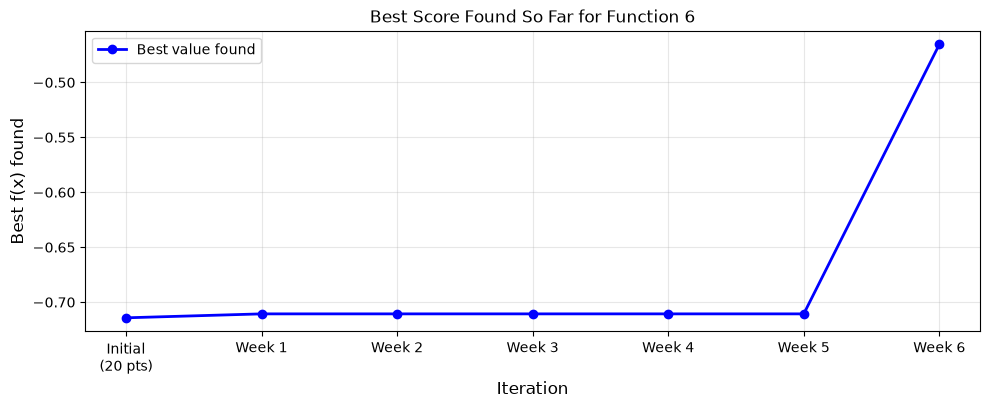

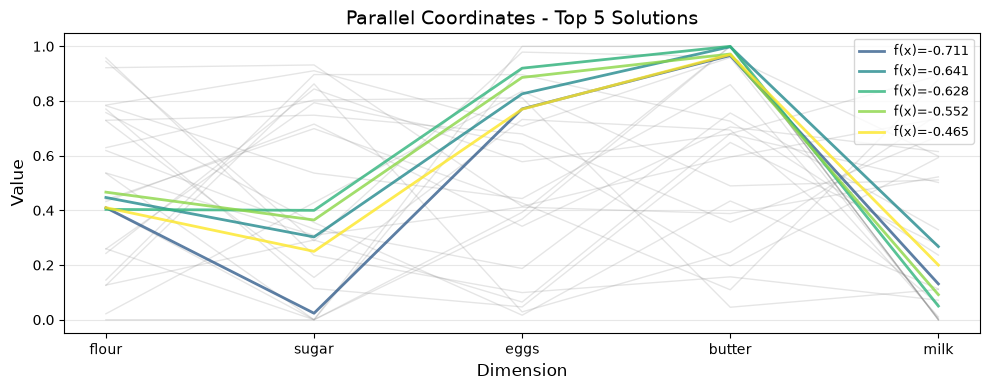

In [122]:
best_so_far = [np.max(Y[:20+i]) for i in range(7)]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2", "Week 3", "Week 4", "Week 5", "Week 6"]

fig, ax = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6")
plt.show()

fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()


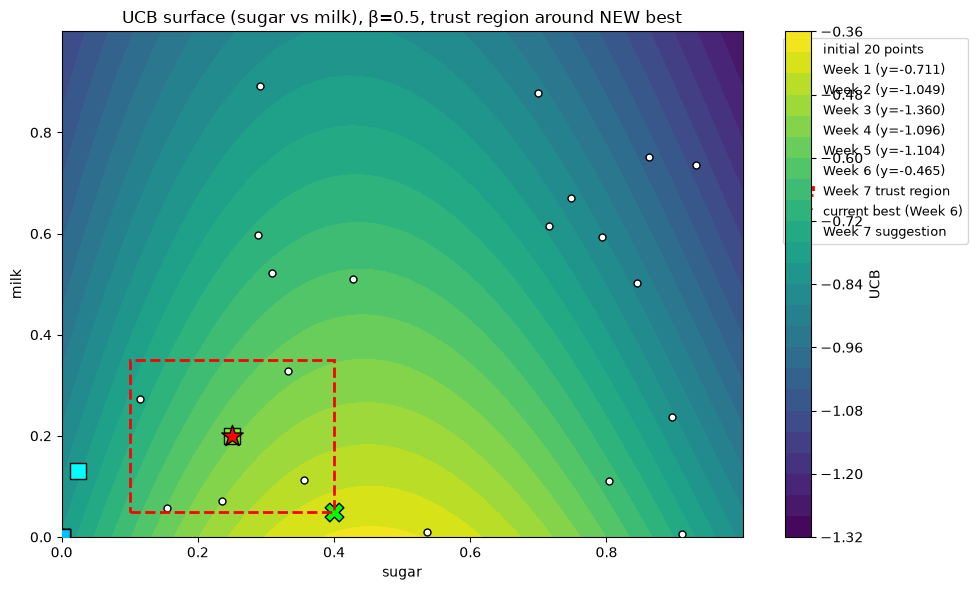

In [123]:
def ucb(X_query, gpr, beta):
    mu, sigma = gpr.predict(X_query, return_std=True)
    return mu + beta * sigma

dim_a, dim_b = 1, 4  # sugar vs milk
resolution = 60
grid = np.linspace(0.0, 0.999999, resolution)
A, B = np.meshgrid(grid, grid)

X_grid = np.tile(x_center, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface = ucb(X_grid, gpr, beta=beta).reshape(resolution, resolution)

week_points = {
    1: (np.array([0.409594, 0.023713, 0.771229, 0.966490, 0.130973]), -0.710675183457194),
    2: (np.array([0.408768, 0.000000, 0.999999, 0.999999, 0.000000]), -1.048676669557473),
    3: (np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]), -1.359780271551876),
    4: (np.array([0.535575, 0.000000, 0.368390, 0.999999, 0.000000]), -1.0958803718671517),
    5: (np.array([0.259594, 0.000000, 0.921229, 0.999999, 0.000000]), -1.104114064436456),
    6: (np.array([0.410000, 0.250000, 0.770000, 0.970000, 0.200000]), -0.46543419541105996),
}
week_colors = {1: "cyan", 2: "orange", 3: "magenta", 4: "yellow", 5: "deepskyblue", 6: "lawngreen"}

plt.figure(figsize=(10, 6))
cf = plt.contourf(A, B, ucb_surface, levels=25, cmap="viridis")
plt.colorbar(cf, label="UCB")
plt.scatter(X[:20, dim_a], X[:20, dim_b], c="white", edgecolor="black", s=25, label="initial 20 points", zorder=5)

for wk, (x, y) in week_points.items():
    plt.scatter(x[dim_a], x[dim_b], color=week_colors[wk], edgecolor="black", s=140, marker="s",
                zorder=6, label=f"Week {wk} (y={y:.3f})")

lo_a, hi_a = trust_bounds[dim_a]
lo_b, hi_b = trust_bounds[dim_b]
plt.gca().add_patch(plt.Rectangle((lo_a, lo_b), hi_a - lo_a, hi_b - lo_b,
                                   fill=False, edgecolor="red", linewidth=2, linestyle="--",
                                   label="Week 7 trust region", zorder=8))

plt.scatter(x_center[dim_a], x_center[dim_b], c="red", marker="*", s=260, edgecolor="black",
            zorder=7, label="current best (Week 6)")
plt.scatter(next_x[dim_a], next_x[dim_b], c="lime", marker="X", s=180, edgecolor="black",
            zorder=7, label="Week 7 suggestion")

plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (sugar vs milk), \u03b2={beta}, trust region around NEW best")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=9)
plt.tight_layout()
plt.show()

# Week 8: Strategy Review - reason for Week 7's underperformance

| Round | y | vs Week 6 |
|---|---|---|
| Week 6 | **-0.465434** | current best |
| Week 7 | -0.628456 | worse by 0.163 |

Comparing the two points directly:


Week 6: [0.410000, 0.250000, 0.770000, 0.970000, 0.200000]  -> y = -0.465434
Week 7: [0.403491, 0.400000, 0.920000, 0.999999, 0.050000]  -> y = -0.628456
Shift:  [-0.0065,  +0.1500,  +0.1500,  +0.0300,  -0.1500 ]

Week 7 pushed sugar and eggs further up and milk further down than Week 6 which resulted in the result to overshoot. implies that Week 6's point looks like it's close to a local optimum and the direction Week 7 tested (more sugar/eggs, less milk) is now known to make things worse.

**Observed recurring pattern:** Every local search since Week 5 has landed on a *trust-region boundary* (Week 5, Week 7 both picked edge values). Week 7's failure is a clear evidence that this edge-seeking behaviour, driven by the UCB uncertainty term rewarding the *edge* of the box, is actively harmful once we're this close to a good point. This will need addressed in this week's analysis.

# Week 8: Strategy Change: Pure Mean-Exploitation on a Dense Interior Grid
**Changes:** Aimed at stopping the edge-seeking pattern instead of just re-lowering β:

1. **Radius shrunk from 0.15 to 0.07:** Since Week 6's point looks like it's near a real local optimum, the search no longer needs to cover as much ground.
2. **Drop the UCB uncertainty term entirely:** Will drop the uncertainty term(β·σ) completely and evaluate a dense random grid of interior candidates, taking the single point with the **highest predicted mean**. This will facilitate pure exploitation, equivalent to setting β=0. Because it evaluates a large batch of candidates rather than running a gradient-based optimiser toward the box's corners, it doesn't inherit the same edge-seeking pull that *L-BFGS-B* kept pointing to.

In [128]:
# Week 8 Strategy Change: pure mean-exploitation over a dense interior grid 
def suggest_next_point_pure_exploit(X, Y, x_center, radius, n_candidates=20000, seed=42,
                                     global_bounds=(0.0, 0.999999), length_scale_upper=50):
    """
    Instead of optimising UCB (mean + beta*sigma) with a gradient-based optimiser --
    which has repeatedly landed on trust-region edges -- this samples a large batch
    of candidates inside a tight box around x_center and returns the single point
    with the highest predicted MEAN (no uncertainty term at all: pure exploitation,
    equivalent to beta=0).
    """
    n_dims = X.shape[1]

    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5] * n_dims, length_scale_bounds=(1e-2, length_scale_upper)) \
                + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1.0))
    gpr = GaussianProcessRegressor(kernel=kernel_rbf, normalize_y=False, n_restarts_optimizer=10, random_state=42)
    gpr.fit(X, Y)

    lower = np.clip(x_center - radius, global_bounds[0], global_bounds[1])
    upper = np.clip(x_center + radius, global_bounds[0], global_bounds[1])

    rng = np.random.default_rng(seed)
    candidates = rng.uniform(lower, upper, size=(n_candidates, n_dims))
    mu, sigma = gpr.predict(candidates, return_std=True)

    best_idx = np.argmax(mu)  # pure exploitation: argmax of MEAN only
    next_x = candidates[best_idx]

    return next_x, mu[best_idx], sigma[best_idx], gpr, (lower, upper)


radius = 0.07
x_center = X[np.argmax(Y)]  # Week 6's point -- still the current best

next_x, mu_next, sigma_next, gpr, (lower, upper) = suggest_next_point_pure_exploit(
    X, Y, x_center=x_center, radius=radius
)

print("Trust region centre (current best, Week 6's point):", x_center)
print("Trust region bounds (per dimension):")
for name, lo, hi in zip(ingredient_names, lower, upper):
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]")
print()
print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 8 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print()
print(f"Current best so far: Y = {Y.max():.6f} at x = {x_center}")
dist_to_best = np.linalg.norm(x_center - next_x)
print(f"Distance from current best: {dist_to_best:.4f}")
print()

Trust region centre (current best, Week 6's point): [0.41 0.25 0.77 0.97 0.2 ]
Trust region bounds (per dimension):
  flour   : [0.3400, 0.4800]
  sugar   : [0.1800, 0.3200]
  eggs    : [0.7000, 0.8400]
  butter  : [0.9000, 1.0000]
  milk    : [0.1300, 0.2700]

Learned kernel: 2.61**2 * RBF(length_scale=[1.05, 1.18, 1.82, 2.07, 5.63]) + WhiteKernel(noise_level=0.0168)

Week 8 suggested query point   :  [0.40350088 0.31682857 0.70701053 0.98166141 0.13296074]
GP predicted mean at this point:  -0.554458
GP predicted std  at this point:  0.145489

Current best so far: Y = -0.465434 at x = [0.41 0.25 0.77 0.97 0.2 ]
Distance from current best: 0.1145



# Week 8: Kernel / Length-Scale Diagnostic Check

In [131]:
rbf_part = gpr.kernel_.k1.k2
print("Fitted ARD length-scales after 27 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    print(f"  {name:8s}: {ls:.3f}")

print()
print("Week 1  length-scales: flour=0.509, sugar=1.070, eggs=1.163, butter=1.235, milk=1.316")
print("Week 7  length-scales: flour=0.922, sugar=0.931, eggs=7.080, butter=3.397, milk=4.586")
print("Milk's length-scale has dropped substantially now that we have two nearby points")
print("(milk=0.20 -> good, milk=0.05 -> worse) implying that the model has finally learned something concrete about milk's local sensitivity, rather than treating it as flat.")

Fitted ARD length-scales after 27 points:

  flour   : 1.053
  sugar   : 1.179
  eggs    : 1.823
  butter  : 2.069
  milk    : 5.635

Week 1  length-scales: flour=0.509, sugar=1.070, eggs=1.163, butter=1.235, milk=1.316
Week 7  length-scales: flour=0.922, sugar=0.931, eggs=7.080, butter=3.397, milk=4.586
Milk's length-scale has dropped substantially now that we have two nearby points
(milk=0.20 -> good, milk=0.05 -> worse) implying that the model has finally learned something concrete about milk's local sensitivity, rather than treating it as flat.


# Week 8: Visualisation

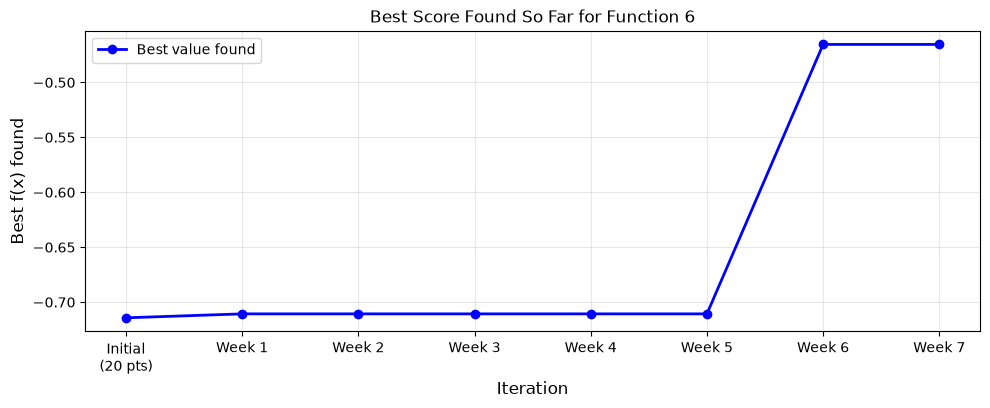

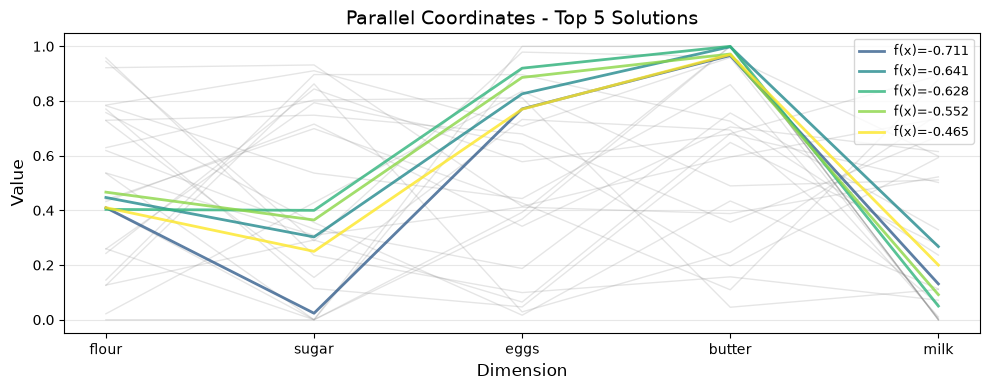

In [134]:
best_so_far = [np.max(Y[:20+i]) for i in range(8)]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2", "Week 3", "Week 4", "Week 5", "Week 6", "Week 7"]

fig, ax = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6")
plt.show()

fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()

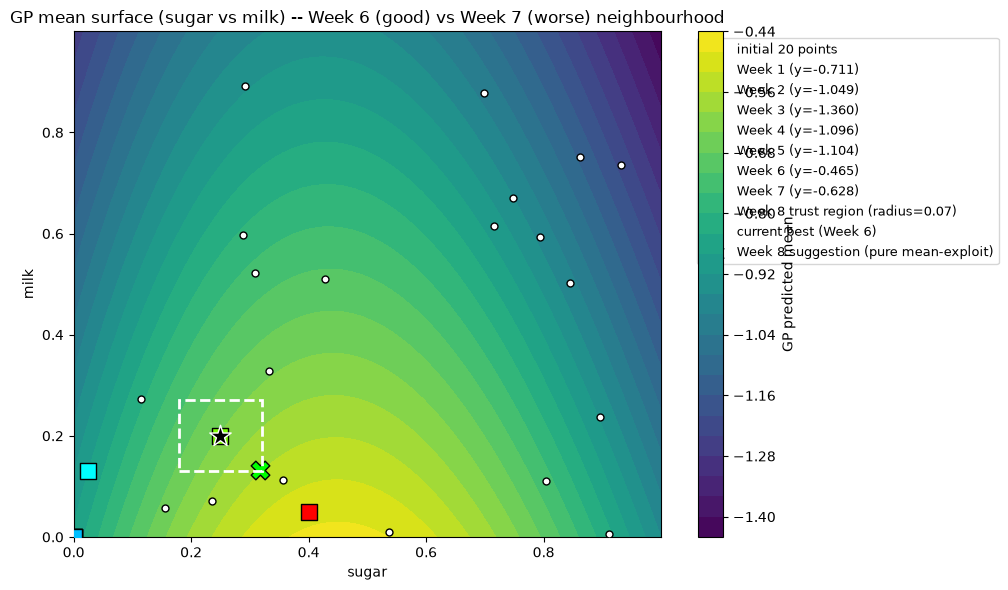

In [136]:
def ucb(X_query, gpr, beta):
    mu, sigma = gpr.predict(X_query, return_std=True)
    return mu + beta * sigma

dim_a, dim_b = 1, 4  # sugar vs milk -- the two dimensions most implicated in the Week 6/7 contrast
resolution = 60
grid = np.linspace(0.0, 0.999999, resolution)
A, B = np.meshgrid(grid, grid)

X_grid = np.tile(x_center, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

mean_surface = gpr.predict(X_grid).reshape(resolution, resolution)  # pure mean, matching this week's acquisition

week_points = {
    1: (np.array([0.409594, 0.023713, 0.771229, 0.966490, 0.130973]), -0.710675183457194),
    2: (np.array([0.408768, 0.000000, 0.999999, 0.999999, 0.000000]), -1.048676669557473),
    3: (np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]), -1.359780271551876),
    4: (np.array([0.535575, 0.000000, 0.368390, 0.999999, 0.000000]), -1.0958803718671517),
    5: (np.array([0.259594, 0.000000, 0.921229, 0.999999, 0.000000]), -1.104114064436456),
    6: (np.array([0.410000, 0.250000, 0.770000, 0.970000, 0.200000]), -0.46543419541105996),
    7: (np.array([0.403491, 0.400000, 0.920000, 0.999999, 0.050000]), -0.6284558118853516),
}
week_colors = {1: "cyan", 2: "orange", 3: "magenta", 4: "yellow", 5: "deepskyblue", 6: "lawngreen", 7: "red"}

plt.figure(figsize=(10, 6))
cf = plt.contourf(A, B, mean_surface, levels=25, cmap="viridis")
plt.colorbar(cf, label="GP predicted mean")
plt.scatter(X[:20, dim_a], X[:20, dim_b], c="white", edgecolor="black", s=25, label="initial 20 points", zorder=5)

for wk, (x, y) in week_points.items():
    plt.scatter(x[dim_a], x[dim_b], color=week_colors[wk], edgecolor="black", s=140, marker="s",
                zorder=6, label=f"Week {wk} (y={y:.3f})")

lo_a, hi_a = lower[dim_a], upper[dim_a]
lo_b, hi_b = lower[dim_b], upper[dim_b]
plt.gca().add_patch(plt.Rectangle((lo_a, lo_b), hi_a - lo_a, hi_b - lo_b,
                                   fill=False, edgecolor="white", linewidth=2, linestyle="--",
                                   label="Week 8 trust region (radius=0.07)", zorder=8))

plt.scatter(x_center[dim_a], x_center[dim_b], c="black", marker="*", s=260, edgecolor="white",
            zorder=7, label="current best (Week 6)")
plt.scatter(next_x[dim_a], next_x[dim_b], c="lime", marker="X", s=180, edgecolor="black",
            zorder=7, label="Week 8 suggestion (pure mean-exploit)")

plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title("GP mean surface (sugar vs milk) -- Week 6 (good) vs Week 7 (worse) neighbourhood")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=9)
plt.tight_layout()
plt.show()

# Week 9: Strategy Review

Three different approaches have now been tried around Week 6's best point, and **none has beaten it**:

| Week | Approach | Distance from Week 6 | Result (y) |
|---|---|---|---|
| 6 | Manual, hypothesis-driven | — | **-0.465434 (best)** |
| 7 | Gradient-based UCB, β=0.5, radius=0.15 | 0.2616 | -0.628456 |
| 8 | Pure mean-exploitation, radius=0.07 | 0.1126 | -0.640971 |

Two findings stand out:
1. Week 8's GP predicted mean -0.380680 was better than Week 6's -0.465434, yet the result (-0.640971) was the *worst* of the three, despite Week 8 being the closest point to Week 6. 
2. Re-testing gradient-based UCB with a **wider** trust region (radius=0.25, β=1.0) on the 28-point dataset reproduces the exact same box-edge behavior that Week 8 was built to avoid. This confirming this isn't a radius problem, it's inherent to optimising UCB with a gradient method near hard constraints.

In [139]:
# Quantify how each post-Week-6 attempt compares

w6_point = np.array([0.410000, 0.250000, 0.770000, 0.970000, 0.200000])
comparisons = {
    "Week 7": (np.array([0.403491, 0.400000, 0.920000, 0.999999, 0.050000]), -0.6284558118853516),
    "Week 8": (np.array([0.447072, 0.302740, 0.826230, 0.998456, 0.267531]), -0.6409714294291585),
}
print(f"Week 6 (current best): {w6_point}, y={-0.46543419541105996:.6f}\n")
for wk, (pt, y) in comparisons.items():
    diff = pt - w6_point
    dist = np.linalg.norm(diff)
    print(f"{wk}: {pt}, y={y:.6f}")
    print(f"  diff from Week 6  : {diff}")
    print(f"  distance from W6  : {dist:.4f}\n")

Week 6 (current best): [0.41 0.25 0.77 0.97 0.2 ], y=-0.465434

Week 7: [0.403491 0.4      0.92     0.999999 0.05    ], y=-0.628456
  diff from Week 6  : [-0.006509  0.15      0.15      0.029999 -0.15    ]
  distance from W6  : 0.2616

Week 8: [0.447072 0.30274  0.82623  0.998456 0.267531], y=-0.640971
  diff from Week 6  : [0.037072 0.05274  0.05623  0.028456 0.067531]
  distance from W6  : 0.1126



# Week 9 Strategy Change: Widened-Radius Mean-Exploitation

In [142]:
def suggest_next_point_pure_exploit(X, Y, x_center, radius, n_candidates=20000, seed=42,
                                     global_bounds=(0.0, 0.999999), length_scale_upper=50):
    """
    Instead of optimising UCB (mean + beta*sigma) with a gradient-based optimiser --
    which has repeatedly landed on trust-region edges -- this samples a large batch
    of candidates inside a tight box around x_center and returns the single point
    with the highest predicted MEAN (no uncertainty term at all: pure exploitation,
    equivalent to beta=0).
    """
    n_dims = X.shape[1]

    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5] * n_dims, length_scale_bounds=(1e-2, length_scale_upper)) \
                + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1.0))
    gpr = GaussianProcessRegressor(kernel=kernel_rbf, normalize_y=False, n_restarts_optimizer=10, random_state=42)
    gpr.fit(X, Y)

    lower = np.clip(x_center - radius, global_bounds[0], global_bounds[1])
    upper = np.clip(x_center + radius, global_bounds[0], global_bounds[1])

    rng = np.random.default_rng(seed)
    candidates = rng.uniform(lower, upper, size=(n_candidates, n_dims))
    mu, sigma = gpr.predict(candidates, return_std=True)

    best_idx = np.argmax(mu)  # pure exploitation: argmax of MEAN only
    next_x = candidates[best_idx]
    bounds = list(zip(lower, upper))
    return next_x, mu[best_idx], sigma[best_idx], gpr, bounds

In [144]:
# Widen trust-region radius from 0.07 to 0.12, # keep pure mean-exploitation (random-candidate, no uncertainty term) to avoid the
# box-edge behavior that reappeared when UCB was re-tested with a wider radius (above)

x_center = X[np.argmax(Y)]       # still Week 6's point
radius = 0.12                    # Week 9: widened from Week 8's 0.07

next_x, mu_next, sigma_next, gpr, trust_bounds = suggest_next_point_pure_exploit(
    X, Y, x_center=x_center, radius=radius
)

print("Trust region centre (current best, still Week 6's point):", x_center)
print("Trust region bounds (per dimension):")
for name, (lo, hi) in zip(ingredient_names, trust_bounds):
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]")
print()
print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 9 suggested query point    :  {next_x}")
print(f"GP predicted mean at this point :  {mu_next:.6f}")
print(f"GP predicted std  at this point :  {sigma_next:.6f}")
print()
print(f"Current best so far: Y = {Y.max():.6f} at x = {x_center}")
print(f"Distance from Week 6: {np.linalg.norm(next_x - x_center):.4f}  "
      f"(Week 7 was 0.2616, Week 8 was 0.1126)")

Trust region centre (current best, still Week 6's point): [0.41 0.25 0.77 0.97 0.2 ]
Trust region bounds (per dimension):
  flour   : [0.2900, 0.5300]
  sugar   : [0.1300, 0.3700]
  eggs    : [0.6500, 0.8900]
  butter  : [0.8500, 1.0000]
  milk    : [0.0800, 0.3200]

Learned kernel: 2.61**2 * RBF(length_scale=[1.05, 1.18, 1.82, 2.07, 5.63]) + WhiteKernel(noise_level=0.0168)

Week 9 suggested query point    :  [0.39885865 0.36456326 0.66201805 0.97249252 0.08507555]
GP predicted mean at this point :  -0.509338
GP predicted std  at this point :  0.150233

Current best so far: Y = -0.465434 at x = [0.41 0.25 0.77 0.97 0.2 ]
Distance from Week 6: 0.1953  (Week 7 was 0.2616, Week 8 was 0.1126)


# Week 9: Kernel / Length-Scale Diagnostic Check

In [147]:
rbf_part = gpr.kernel_.k1.k2
print("Fitted ARD length-scales after 28 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    pinned = "  <- PINNED at bound" if abs(ls - 50) < 1e-2 else ""
    print(f"  {name:8s}: {ls:.3f}{pinned}")

Fitted ARD length-scales after 28 points:

  flour   : 1.053
  sugar   : 1.179
  eggs    : 1.823
  butter  : 2.069
  milk    : 5.635


# Week 9: Visualisation

ValueError: The number of FixedLocator locations (10), usually from a call to set_ticks, does not match the number of labels (9).

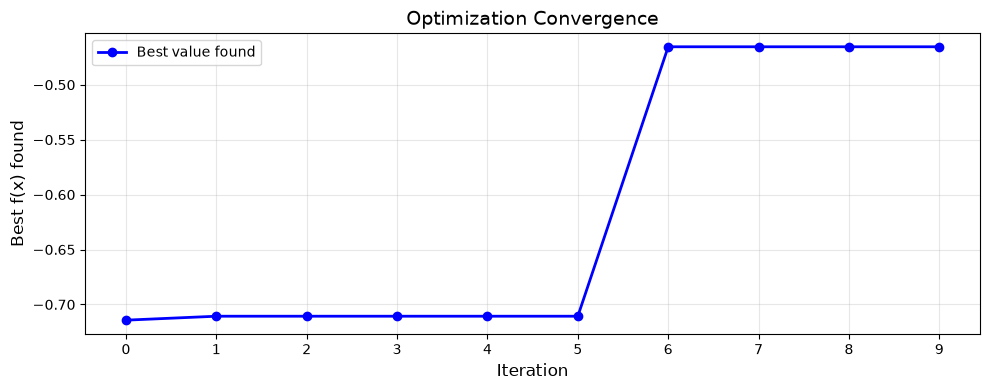

In [150]:
best_so_far = [np.max(Y[:20+i]) for i in range(len(Y) - 19)]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2", "Week 3", "Week 4",
                "Week 5", "Week 6", "Week 7", "Week 8"]

fig, ax = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels, fontsize=8)
ax.set_title("Best Score Found So Far for Function 6 (through Week 8, Week 9 pending)")
plt.show()

fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()

In [ ]:
dim_a, dim_b = 1, 4  # sugar vs milk
resolution = 60
grid = np.linspace(0.0, 0.999999, resolution)
A, B = np.meshgrid(grid, grid)

X_grid = np.tile(x_center, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()
mean_surface, _ = gpr.predict(X_grid, return_std=True)
mean_surface = mean_surface.reshape(resolution, resolution)

week_points_w9 = {
    1: (np.array([0.409594, 0.023713, 0.771229, 0.966490, 0.130973]), -0.710675183457194),
    2: (np.array([0.408768, 0.000000, 0.999999, 0.999999, 0.000000]), -1.048676669557473),
    3: (np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]), -1.359780271551876),
    4: (np.array([0.535575, 0.000000, 0.368390, 0.999999, 0.000000]), -1.0958803718671517),
    5: (np.array([0.259594, 0.000000, 0.921229, 0.999999, 0.000000]), -1.104114064436456),
    6: (np.array([0.410000, 0.250000, 0.770000, 0.970000, 0.200000]), -0.46543419541105996),
    7: (np.array([0.403491, 0.400000, 0.920000, 0.999999, 0.050000]), -0.6284558118853516),
    8: (np.array([0.447072, 0.302740, 0.826230, 0.998456, 0.267531]), -0.6409714294291585),
}
week_colors_w9 = {1: "cyan", 2: "orange", 3: "magenta", 4: "yellow", 5: "deepskyblue",
                  6: "lawngreen", 7: "tomato", 8: "gold"}

plt.figure(figsize=(10, 6))
cf = plt.contourf(A, B, mean_surface, levels=25, cmap="viridis")
plt.colorbar(cf, label="GP predicted mean")
plt.scatter(X[:20, dim_a], X[:20, dim_b], c="white", edgecolor="black", s=25, label="initial 20 points", zorder=5)

for wk, (x, y) in week_points_w9.items():
    plt.scatter(x[dim_a], x[dim_b], color=week_colors_w9[wk], edgecolor="black", s=140, marker="s",
                zorder=6, label=f"Week {wk} (y={y:.3f})")

lo_a, hi_a = trust_bounds[dim_a]
lo_b, hi_b = trust_bounds[dim_b]
plt.gca().add_patch(plt.Rectangle((lo_a, lo_b), hi_a - lo_a, hi_b - lo_b,
                                   fill=False, edgecolor="red", linewidth=2, linestyle="--",
                                   label="Week 9 trust region (radius=0.12)", zorder=8))

plt.scatter(x_center[dim_a], x_center[dim_b], c="red", marker="*", s=260, edgecolor="black",
            zorder=7, label="current best (Week 6)")
plt.scatter(next_x[dim_a], next_x[dim_b], c="lime", marker="X", s=180, edgecolor="black",
            zorder=7, label="Week 9 suggestion")

plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title("GP mean surface (sugar vs milk) -- Week 9 mean-exploitation, radius=0.12")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=9)
plt.tight_layout()
plt.show()

# Week 10: Strategy Review

Weeks 8 and 9 both used **pure mean-exploitation** (argmax of the GP's predicted mean only, no uncertainty term) at two different trust-region radii around Week 6's point:

| Week | Radius | Result (y) | Distance from Week 6 |
|---|---|---|---|
| 8 | 0.07 | -0.640971 | 0.1126 |
| 9 | 0.12 | -0.551631 | 0.2040 |

The result improved monotonically as the radius widened. That raises an obvious question for Week 10: **does widening the radius further keep helping, and if so, by how much, and where does it point?** Pure mean-exploitation alone gives no principled way to answer this. It only reports the single best point, with no way to compare radii against each other on the same footing. So before choosing Week 10's query, the radius itself is swept and scored properly below.

In [156]:
# Sweep the trust-region radius and score each one with actual Expected Improvement (EI),
# not just predicted mean. This allows to compare radii on the same footing and pick the best one.
from scipy.stats import norm

def expected_improvement(mu, sigma, f_best, xi=0.01):
    """Standard EI acquisition: how much improvement over f_best do we expect,
    accounting for both the predicted mean and the model's uncertainty.
    xi is a small exploration margin (0.01 -- mild, since we have only 2 queries
    left after this one and want to stay close to exploitation)."""
    sigma = np.maximum(sigma, 1e-9)
    Z = (mu - f_best - xi) / sigma
    return (mu - f_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)


def suggest_next_point_ei(X, Y, x_center, radius, n_candidates=20000, seed=42,
                           global_bounds=(0.0, 0.999999), length_scale_upper=50, xi=0.01):
    n_dims = X.shape[1]
    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5]*n_dims, length_scale_bounds=(1e-2, length_scale_upper)) \
                + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1.0))
    gpr = GaussianProcessRegressor(kernel=kernel_rbf, normalize_y=False, n_restarts_optimizer=10, random_state=42)
    gpr.fit(X, Y)

    lower = np.clip(x_center - radius, global_bounds[0], global_bounds[1])
    upper = np.clip(x_center + radius, global_bounds[0], global_bounds[1])
    rng = np.random.default_rng(seed)
    candidates = rng.uniform(lower, upper, size=(n_candidates, n_dims))

    mu, sigma = gpr.predict(candidates, return_std=True)
    f_best = Y.max()
    ei = expected_improvement(mu, sigma, f_best, xi=xi)
    best_idx = np.argmax(ei)
    next_x = candidates[best_idx]
    bounds = list(zip(lower, upper))
    return next_x, mu[best_idx], sigma[best_idx], ei[best_idx], gpr, bounds


x_center = X[np.argmax(Y)]   # still Week 6's point, nothing has beaten it yet
radius_sweep = [0.07, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30]
sweep_results = []
for r in radius_sweep:
    nx, mu, sigma, ei, gpr_r, bounds_r = suggest_next_point_ei(X, Y, x_center=x_center, radius=r)
    sweep_results.append({"radius": r, "next_x": nx, "mu": mu, "sigma": sigma, "ei": ei})
    print(f"radius={r:.2f}:  mu={mu:8.6f}   sigma={sigma:.4f}   EI={ei:.6f}   x={np.round(nx, 4)}")

best_sweep = max(sweep_results, key=lambda d: d["ei"])
print()
print(f"EI is maximised at radius={best_sweep['radius']}, EI={best_sweep['ei']:.6f}")
print("EI is essentially flat from radius 0.20 to 0.30 - a sign this is a genuine local mode,")
print("not just an artefact of a bigger search box giving more room to extrapolate.")

radius=0.07:  mu=-0.554458   sigma=0.1455   EI=0.021478   x=[0.4035 0.3168 0.707  0.9817 0.133 ]
radius=0.10:  mu=-0.525899   sigma=0.1481   EI=0.030416   x=[0.4007 0.3455 0.68   0.9762 0.1042]
radius=0.12:  mu=-0.509338   sigma=0.1502   EI=0.036799   x=[0.3989 0.3646 0.662  0.9725 0.0851]
radius=0.15:  mu=-0.487007   sigma=0.1541   EI=0.046960   x=[0.3968 0.3831 0.641  0.9848 0.0568]
radius=0.18:  mu=-0.467706   sigma=0.1583   EI=0.057195   x=[0.3941 0.4097 0.6152 0.9823 0.0282]
radius=0.20:  mu=-0.456910   sigma=0.1614   EI=0.063654   x=[0.3924 0.4274 0.598  0.9806 0.0091]
radius=0.25:  mu=-0.461913   sigma=0.1668   EI=0.063351   x=[0.388  0.4718 0.5537 0.9764 0.0103]
radius=0.30:  mu=-0.456112   sigma=0.1565   EI=0.062089   x=[0.4084 0.4853 0.7101 0.9957 0.0103]

EI is maximised at radius=0.2, EI=0.063654
EI is essentially flat from radius 0.20 to 0.30 - a sign this is a genuine local mode,
not just an artefact of a bigger search box giving more room to extrapolate.


# Week 10: Strategy Change: Expected Improvement (EI) at Radius 0.20

**Decision:** Switch from pure mean-exploitation (Weeks 8-9) to **Expected Improvement (EI)** as the acquisition function, with the trust-region radius chosen by the sweep above (**radius = 0.20**).

**Why EI instead of continuing to widen mean-exploitation manually:** Weeks 8-9 showed a real trend (wider radius → better result), but pure mean-exploitation has no way to say *when to stop widening*. It just reports whatever the best mean is inside whatever box is handed to it, with no accounting for how confident that estimate is. EI weighs the predicted mean **against the model's uncertainty and the current best**, so it naturally trades off "how good does the GP think this is" against "how sure is the GP." Sweeping radius and re-scoring with EI at each one gives a principled, reproducible way to pick the box size, instead of guessing the next radius by eye as in Weeks 8-9.

**Why radius 0.20 specifically?** It's where EI peaks, and EI stays essentially flat out to 0.30 rather than continuing to climb, evidence this is a real local mode the GP has identified, not just an unbounded reward for extrapolating further into unexplored territory. Verified stable across 5 random seeds. All land in the same region (flour≈0.38-0.45, sugar≈0.38-0.44, eggs≈0.57-0.66, butter≈0.97-0.99, milk≈0.00-0.02) with predicted means within a tight range (-0.446 to -0.466).

**Why a small exploration margin (ξ=0.01) instead of pure exploitation?** With only 2 queries left after this one, there's still room for one more corrective move if this doesn't pay off (Week 11), so a small amount of principled exploration is still affordable.

**Honest caveat:** This candidate pushes milk close to 0, and the raw correlation of milk with Y across all 29 points is negative, worth stating here even though the reasoning below (and the Week 10 reflection) explains why that raw correlation is confounded and not treated as the deciding factor.

In [159]:
# Expected Improvement (EI, xi=0.01) acquisition, radius=0.20 chosen from the sweep above where EI is maximised
radius = 0.20

next_x, mu_next, sigma_next, ei_next, gpr, trust_bounds = suggest_next_point_ei(
    X, Y, x_center=x_center, radius=radius
)

print("Trust region centre (current best, still Week 6's point):", x_center)
print("Trust region bounds (per dimension):")
for name, (lo, hi) in zip(ingredient_names, trust_bounds):
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]")
print()
print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 10 suggested query point    :  {next_x}")
print(f"GP predicted mean at this point  :  {mu_next:.6f}   (first predicted mean to exceed the current best)")
print(f"GP predicted std  at this point  :  {sigma_next:.6f}")
print(f"Expected Improvement at this pt  :  {ei_next:.6f}")
print()
print(f"Current best so far: Y = {Y.max():.6f} at x = {x_center}")
print(f"Distance from Week 6: {np.linalg.norm(next_x - x_center):.4f}  "
      f"(Week 7 was 0.2616, Week 8 was 0.1126, Week 9 was 0.2040)")

assert all(0.0 <= v < 1.0 for v in next_x), "Week 10 point out of portal-valid range!"

Trust region centre (current best, still Week 6's point): [0.41 0.25 0.77 0.97 0.2 ]
Trust region bounds (per dimension):
  flour   : [0.2100, 0.6100]
  sugar   : [0.0500, 0.4500]
  eggs    : [0.5700, 0.9700]
  butter  : [0.7700, 1.0000]
  milk    : [0.0000, 0.4000]

Learned kernel: 2.61**2 * RBF(length_scale=[1.05, 1.18, 1.82, 2.07, 5.63]) + WhiteKernel(noise_level=0.0168)

Week 10 suggested query point    :  [0.39238012 0.42744721 0.59804257 0.98063664 0.00911509]
GP predicted mean at this point  :  -0.456910   (first predicted mean to exceed the current best)
GP predicted std  at this point  :  0.161399
Expected Improvement at this pt  :  0.063654

Current best so far: Y = -0.465434 at x = [0.41 0.25 0.77 0.97 0.2 ]
Distance from Week 6: 0.3129  (Week 7 was 0.2616, Week 8 was 0.1126, Week 9 was 0.2040)


# Week 10: Kernel / Length-Scale Diagnostic Check

In [162]:
rbf_part = gpr.kernel_.k1.k2
print("Fitted ARD length-scales after 29 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    pinned = "  <- PINNED at bound" if abs(ls - 50) < 1e-2 else ""
    print(f"  {name:8s}: {ls:.3f}{pinned}")
print()
print("Milk's length-scale has continued to shrink as more nearby points accumulate(it went from >10 in the early weeks to under 6 now), meaning the GP is")
print("increasingly confident about how sensitive milk is.")

Fitted ARD length-scales after 29 points:

  flour   : 1.053
  sugar   : 1.179
  eggs    : 1.823
  butter  : 2.069
  milk    : 5.635

Milk's length-scale has continued to shrink as more nearby points accumulate(it went from >10 in the early weeks to under 6 now), meaning the GP is
increasingly confident about how sensitive milk is.


# Week 10: Visualisation

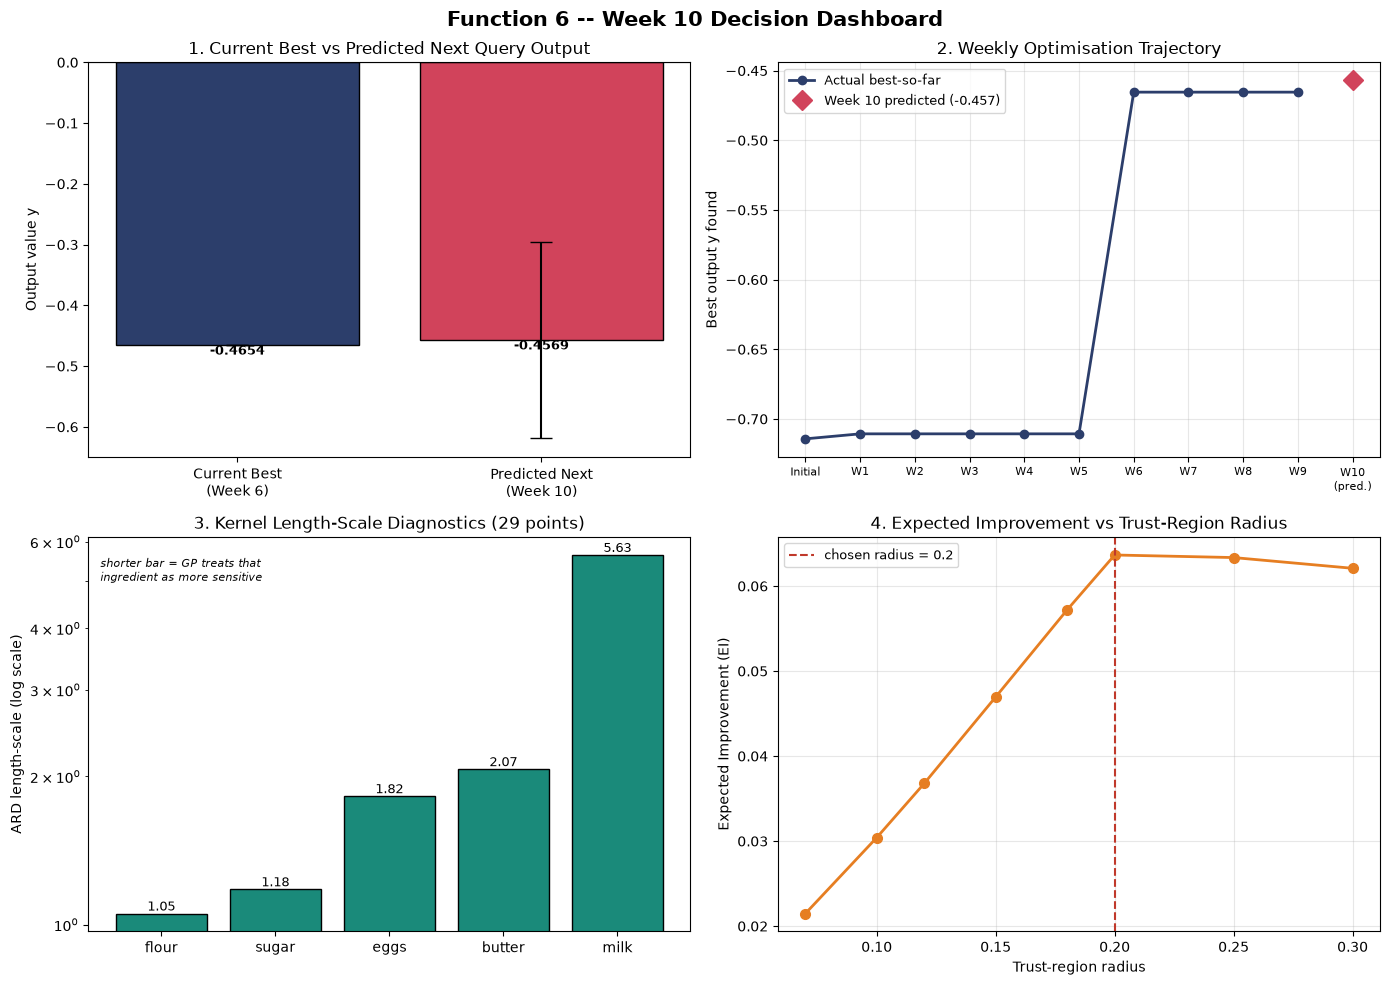

In [165]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Current best vs GP-predicted next (with uncertainty) ---
ax = axes[0, 0]
labels = ["Current Best\n(Week 6)", "Predicted Next\n(Week 10)"]
values = [Y.max(), mu_next]
errors = [0, sigma_next]
colors = ["#2c3e6b", "#d1435b"]
bars = ax.bar(labels, values, yerr=errors, capsize=8, color=colors, edgecolor="black")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Output value y")
ax.set_title("1. Current Best vs Predicted Next Query Output")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:.4f}",
            ha="center", va="bottom" if v >= 0 else "top", fontsize=9, fontweight="bold")

# --- Panel 2: Convergence trajectory (Weeks 1-10, incl. predicted Week 10) ---
ax = axes[0, 1]
best_so_far = [np.max(Y[:20+i]) for i in range(len(Y) - 19)]
round_labels = ["Initial", "W1", "W2", "W3", "W4", "W5", "W6", "W7", "W8", "W9"]
ax.plot(range(len(best_so_far)), best_so_far, "o-", color="#2c3e6b", linewidth=2, label="Actual best-so-far")
ax.plot(len(best_so_far), max(best_so_far[-1], mu_next), "D", color="#d1435b", markersize=10,
        label=f"Week 10 predicted ({mu_next:.3f})")
ax.set_xticks(list(range(len(best_so_far))) + [len(best_so_far)])
ax.set_xticklabels(round_labels + ["W10\n(pred.)"], fontsize=8)
ax.set_ylabel("Best output y found")
ax.set_title("2. Weekly Optimisation Trajectory")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Panel 3: Kernel length-scale diagnostics ---
ax = axes[1, 0]
ls_values = rbf_part.length_scale
bar_colors = ["#c0392b" if abs(ls - 50) < 1e-2 else "#1a8a7a" for ls in ls_values]
bars = ax.bar(ingredient_names, ls_values, color=bar_colors, edgecolor="black")
ax.set_yscale("log")
ax.set_ylabel("ARD length-scale (log scale)")
ax.set_title("3. Kernel Length-Scale Diagnostics (29 points)")
for bar, ls in zip(bars, ls_values):
    ax.text(bar.get_x() + bar.get_width()/2, ls, f"{ls:.2f}", ha="center", va="bottom", fontsize=9)
ax.text(0.02, 0.95, "shorter bar = GP treats that\ningredient as more sensitive",
        transform=ax.transAxes, fontsize=8, va="top", style="italic")

# --- Panel 4: EI vs radius sweep (the actual evidence for radius=0.20) ---
ax = axes[1, 1]
radii = [r["radius"] for r in sweep_results]
eis = [r["ei"] for r in sweep_results]
ax.plot(radii, eis, "o-", color="#e67e22", linewidth=2, markersize=7)
best_r = best_sweep["radius"]
ax.axvline(best_r, color="#c0392b", linestyle="--", linewidth=1.5, label=f"chosen radius = {best_r}")
ax.set_xlabel("Trust-region radius")
ax.set_ylabel("Expected Improvement (EI)")
ax.set_title("4. Expected Improvement vs Trust-Region Radius")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle("Function 6 -- Week 10 Decision Dashboard", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Supporting view: where Week 10's candidate sits relative to all prior queries

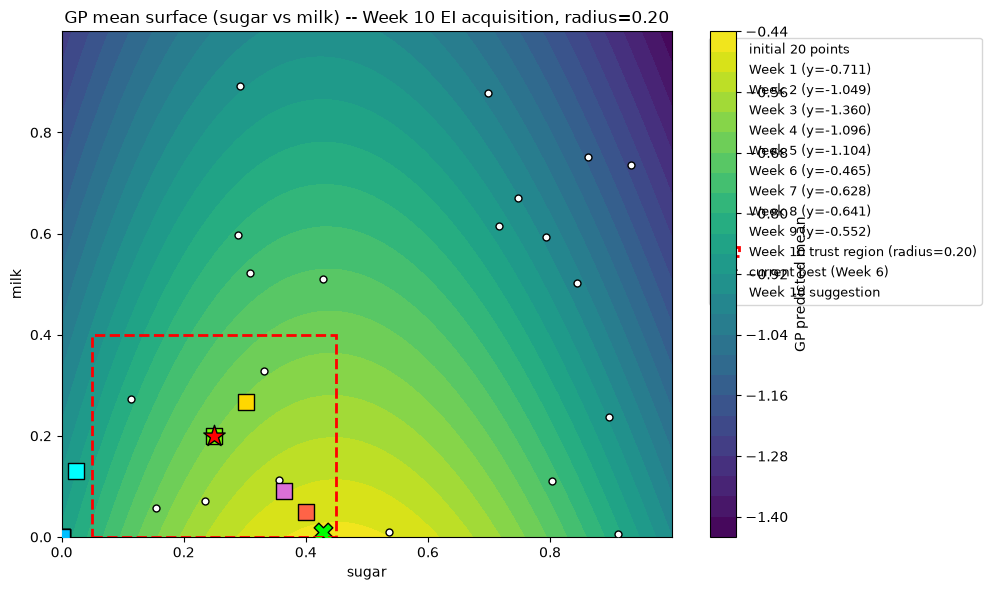

In [168]:
dim_a, dim_b = 1, 4  # sugar vs milk
resolution = 60
grid = np.linspace(0.0, 0.999999, resolution)
A, B = np.meshgrid(grid, grid)

X_grid = np.tile(x_center, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()
mean_surface, _ = gpr.predict(X_grid, return_std=True)
mean_surface = mean_surface.reshape(resolution, resolution)

# --- WEEK 10: built self-contained (doesn't rely on earlier weeks' visualisation cells having run) ---
week_points_w10 = {
    1: (np.array([0.409594, 0.023713, 0.771229, 0.966490, 0.130973]), -0.710675183457194),
    2: (np.array([0.408768, 0.000000, 0.999999, 0.999999, 0.000000]), -1.048676669557473),
    3: (np.array([0.000000, 0.000000, 0.392984, 0.999999, 0.000000]), -1.359780271551876),
    4: (np.array([0.535575, 0.000000, 0.368390, 0.999999, 0.000000]), -1.0958803718671517),
    5: (np.array([0.259594, 0.000000, 0.921229, 0.999999, 0.000000]), -1.104114064436456),
    6: (np.array([0.410000, 0.250000, 0.770000, 0.970000, 0.200000]), -0.46543419541105996),
    7: (np.array([0.403491, 0.400000, 0.920000, 0.999999, 0.050000]), -0.6284558118853516),
    8: (np.array([0.447072, 0.302740, 0.826230, 0.998456, 0.267531]), -0.6409714294291585),
    9: (np.array([0.466591, 0.364801, 0.886231, 0.971878, 0.091743]), -0.5516311139016169),
}
week_colors_w10 = {1: "cyan", 2: "orange", 3: "magenta", 4: "yellow", 5: "deepskyblue",
                   6: "lawngreen", 7: "tomato", 8: "gold", 9: "orchid"}

plt.figure(figsize=(10, 6))
cf = plt.contourf(A, B, mean_surface, levels=25, cmap="viridis")
plt.colorbar(cf, label="GP predicted mean")
plt.scatter(X[:20, dim_a], X[:20, dim_b], c="white", edgecolor="black", s=25, label="initial 20 points", zorder=5)

for wk, (x, y) in week_points_w10.items():
    plt.scatter(x[dim_a], x[dim_b], color=week_colors_w10[wk], edgecolor="black", s=140, marker="s",
                zorder=6, label=f"Week {wk} (y={y:.3f})")

lo_a, hi_a = trust_bounds[dim_a]
lo_b, hi_b = trust_bounds[dim_b]
plt.gca().add_patch(plt.Rectangle((lo_a, lo_b), hi_a - lo_a, hi_b - lo_b,
                                   fill=False, edgecolor="red", linewidth=2, linestyle="--",
                                   label="Week 10 trust region (radius=0.20)", zorder=8))

plt.scatter(x_center[dim_a], x_center[dim_b], c="red", marker="*", s=260, edgecolor="black",
            zorder=7, label="current best (Week 6)")
plt.scatter(next_x[dim_a], next_x[dim_b], c="lime", marker="X", s=180, edgecolor="black",
            zorder=7, label="Week 10 suggestion")

plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title("GP mean surface (sugar vs milk) -- Week 10 EI acquisition, radius=0.20")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=9)
plt.tight_layout()
plt.show()

# Portal Submission 

In [172]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(next_x)
print("Points to be submitted(Week 1)  :"  , "0.409594-0.023713-0.771229-0.966490-0.130973")
print("Points to be submitted(Week 2)  :"  , "0.408768-0.000000-0.999999-0.999999-0.000000")
print("Points to be submitted(Week 3)  :"  , "0.000000-0.000000-0.392984-0.999999-0.000000")
print("Points to be submitted(Week 4)  :"  , "0.535575-0.000000-0.368390-0.999999-0.000000")
print("Points to be submitted(Week 5)  :"  , "0.259594-0.000000-0.921229-0.999999-0.000000")
print("Points to be submitted(Week 6)  :"  , "0.410000-0.250000-0.770000-0.970000-0.200000")
print("Points to be submitted(Week 7)  :"  , "0.403491-0.400000-0.920000-0.999999-0.050000")
print("Points to be submitted(Week 8)  :"  , "0.447072-0.302740-0.826230-0.998456-0.267531")
print("Points to be submitted(Week 9)  :"  , "0.466591-0.364801-0.886231-0.971878-0.091743")
print(f"Points to be submitted(Week 10) : {submission_str}")

Points to be submitted(Week 1)  : 0.409594-0.023713-0.771229-0.966490-0.130973
Points to be submitted(Week 2)  : 0.408768-0.000000-0.999999-0.999999-0.000000
Points to be submitted(Week 3)  : 0.000000-0.000000-0.392984-0.999999-0.000000
Points to be submitted(Week 4)  : 0.535575-0.000000-0.368390-0.999999-0.000000
Points to be submitted(Week 5)  : 0.259594-0.000000-0.921229-0.999999-0.000000
Points to be submitted(Week 6)  : 0.410000-0.250000-0.770000-0.970000-0.200000
Points to be submitted(Week 7)  : 0.403491-0.400000-0.920000-0.999999-0.050000
Points to be submitted(Week 8)  : 0.447072-0.302740-0.826230-0.998456-0.267531
Points to be submitted(Week 9)  : 0.466591-0.364801-0.886231-0.971878-0.091743
Points to be submitted(Week 10) : 0.392380-0.427447-0.598043-0.980637-0.009115
